## Notebook Roadmap

This notebook now has two thesis-facing parts:
1. **Listwise reranking on fixed BM25 candidates**: variance, compute, and learning-efficiency comparisons for REINFORCE, Neural PG-Rank, and PL-Rank.
2. **Toy setwise evidence selection**: Option A (ranking with set reward) and Option B (direct set ranking).

## Minimal Runtime Guide

In a fresh Colab runtime, the usual path is:
1. Mount Drive.
2. `cd` into the repo and run the editable install cell.
3. Run the BEIR HotpotQA + FlashRAG BM25 preparation block.
4. Run the estimator definition cells.
5. Run only the experiment sections you need.

Usually skippable after the first successful setup:
- repo clone, if the repo already exists in Drive
- BM25 index build, if the BEIR/FlashRAG index already exists
- `/content/FlashRAG_local` copy cell, unless later cells explicitly use `/content`

The legacy Java/Pyserini Lucene replication path and older model-download scratch cells were removed from the main workflow to keep this notebook thesis-ready and reproducible.

One-time local data setup if needed: `python scripts/setup_bm25_hotpotqa.py --download_dataset --corpus_path examples/quick_start/indexes/general_knowledge.jsonl --index_dir indexes` now downloads both `train.jsonl` and `dev.jsonl`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # one-time only
# %%bash
# set -e
# cd /content/drive/MyDrive
# git clone https://github.com/Joseph2718/FlashRAG.git

In [2]:
!ls /content/drive/MyDrive/FlashRAG/examples/quick_start/indexes/

e5_Flat.index  general_knowledge.jsonl


In [3]:
%cd /content/drive/MyDrive/FlashRAG

!pip install -e .
!pip install termcolor huggingface_hub

/content/drive/MyDrive/FlashRAG
Obtaining file:///content/drive/MyDrive/FlashRAG
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 143.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.5/811.5 kB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 64.1 MB/s eta 

In [5]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 113.8 MB/s eta 0:00:00


In [6]:
!python scripts/setup_bm25_hotpotqa.py --download_dataset \
    --corpus_path examples/quick_start/indexes/general_knowledge.jsonl \
    --index_dir indexes

HotpotQA train.jsonl already exists at dataset/hotpotqa/train.jsonl
HotpotQA dev.jsonl already exists at dataset/hotpotqa/dev.jsonl
Building BM25 index: /usr/bin/python3 -m flashrag.retriever.index_builder --retrieval_method bm25 --corpus_path examples/quick_start/indexes/general_knowledge.jsonl --save_dir indexes --bm25_backend bm25s
Pooling method not found in None, use default pooling method (mean).
indexes
/content/drive/MyDrive/FlashRAG/flashrag/retriever/index_builder.py:124: UserWarning: Some files already exists in save dir and may be overwritten.
  warnings.warn("Some files already exists in save dir and may be overwritten.", UserWarning)
Generating train split: 15000 examples [00:00, 15151.66 examples/s]
Finish loading...
Finding newlines for mmindex: 100% 6.64M/6.64M [00:00<00:00, 63.1MB/s]
Finish!
BM25 index saved to indexes/bm25

Setup complete. Run BM25 retrieval on HotpotQA with:

cd examples/methods
python run_exp.py --method_name bm25-naive \
    --dataset_name hotpotq

## Legacy Scratch Setup (Collapsed)

Older one-off Colab scratch cells for optional GPU packages, Hugging Face model downloads, `run_exp.py`, and the large wiki BM25 build were removed from the main notebook body.
They were useful during exploration but are not required for the current BEIR/FlashRAG reranking or toy setwise experiments.


In [ ]:
!mkdir -p /content/FlashRAG_local/indexes_wiki/corpus
!mkdir -p /content/FlashRAG_local/indexes_wiki
!mkdir -p /content/FlashRAG_local/dataset

!cp /content/drive/MyDrive/FlashRAG/indexes_wiki/corpus/wiki18_100w.jsonl /content/FlashRAG_local/indexes_wiki/corpus/
!cp -r /content/drive/MyDrive/FlashRAG/indexes_wiki/bm25 /content/FlashRAG_local/indexes_wiki/
!cp -r /content/drive/MyDrive/FlashRAG/dataset/hotpotqa /content/FlashRAG_local/dataset/

## Retrieval Setup: BEIR HotpotQA with FlashRAG BM25

This section fixes the first-stage retriever and candidate pool used by the downstream reranking experiments. We use **BEIR HotpotQA** for queries and qrels, and **FlashRAG BM25** to retrieve the candidate passages.

Why this setup is useful:
- BEIR provides stable query-document relevance labels.
- FlashRAG still provides the BM25 retrieval pipeline and candidate lists.
- The later estimator comparisons therefore study **reranking on a fixed retrieved set**, not end-to-end retrieval.

Important:
- Do not mix BEIR qrels with the earlier `wiki18_100w` corpus; document ids will not match.
- For a quick smoke test, use a small `BEIR_N_QUERIES`; for final figures, set it to `None`.


In [7]:
# If needed in a fresh Colab runtime:
!pip install -q beir faiss-cpu

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval

import json
import os
import pathlib

BEIR_DATASET = "hotpotqa"
BEIR_TRAIN_SPLIT = "train"
BEIR_DEV_SPLIT = "dev"
BEIR_TEST_SPLIT = "test"
BEIR_N_QUERIES = None  # set to None for the full split

beir_root = "/content/drive/MyDrive/FlashRAG/beir_datasets"
os.makedirs(beir_root, exist_ok=True)

url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{BEIR_DATASET}.zip"
data_path = util.download_and_unzip(url, beir_root)


def load_beir_split(split, n_queries=None):
    split_corpus, split_queries_dict, split_qrels = GenericDataLoader(data_folder=data_path).load(split=split)
    split_qids = list(split_queries_dict.keys())
    if n_queries is not None:
        split_qids = split_qids[:n_queries]
    split_queries = [split_queries_dict[qid] for qid in split_qids]
    split_qrels_subset = {qid: split_qrels[qid] for qid in split_qids if qid in split_qrels}
    return {
        "split": split,
        "corpus": split_corpus,
        "queries_dict": split_queries_dict,
        "qrels": split_qrels,
        "qids": split_qids,
        "queries": split_queries,
        "qrels_subset": split_qrels_subset,
    }


beir_train = load_beir_split(BEIR_TRAIN_SPLIT, BEIR_N_QUERIES)
beir_dev = load_beir_split(BEIR_DEV_SPLIT, BEIR_N_QUERIES)
beir_test = load_beir_split(BEIR_TEST_SPLIT, BEIR_N_QUERIES)
beir_query_splits = {
    "train": beir_train,
    "dev": beir_dev,
    "test": beir_test,
}
corpus = beir_train["corpus"]

print(f"Loaded BEIR {BEIR_DATASET} query pools for train/dev/test.")
for split_name, payload in beir_query_splits.items():
    print(f"  {split_name}: {len(payload['qids'])} queries")
print(f"Corpus size: {len(corpus)}")
print("Learned reranking below fits on BEIR train, validates on BEIR dev, and keeps BEIR test for fixed-BM25 reporting only.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 30.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/5233329 [00:00<?, ?it/s]

  0%|          | 0/5233329 [00:00<?, ?it/s]

  0%|          | 0/5233329 [00:00<?, ?it/s]

Loaded BEIR hotpotqa query pools for train/dev/test.
  train: 85000 queries
  dev: 5447 queries
  test: 7405 queries
Corpus size: 5233329
Learned reranking below fits on BEIR train, validates on BEIR dev, and keeps BEIR test for fixed-BM25 reporting only.


In [9]:
import json
import os
import subprocess
import sys

beir_flashrag_root = "/content/drive/MyDrive/FlashRAG/beir_hotpotqa_flashrag"
beir_corpus_path = os.path.join(beir_flashrag_root, f"{BEIR_DATASET}_corpus.jsonl")
beir_index_root = os.path.join(beir_flashrag_root, f"indexes_{BEIR_DATASET}")
beir_index_path = os.path.join(beir_index_root, "bm25")

os.makedirs(beir_flashrag_root, exist_ok=True)
os.makedirs(beir_index_root, exist_ok=True)

rewrite_corpus = (not os.path.exists(beir_corpus_path)) or os.path.getsize(beir_corpus_path) == 0
if rewrite_corpus:
    rows_written = 0
    with open(beir_corpus_path, "w", encoding="utf-8") as handle:
        for pid, doc in corpus.items():
            title = (doc.get("title") or "").strip()
            text = (doc.get("text") or "").strip()
            contents = f"{title}\n{text}" if title else text
            row = {
                "id": str(pid),
                "title": title,
                "text": text,
                "contents": contents,
            }
            handle.write(json.dumps(row, ensure_ascii=False) + "\n")
            rows_written += 1
    print(f"Wrote shared FlashRAG-compatible BEIR corpus to: {beir_corpus_path} ({rows_written} rows)")
else:
    print("Shared FlashRAG-compatible BEIR corpus already exists:", beir_corpus_path)

if not os.path.exists(beir_index_path):
    cmd = [
        sys.executable,
        "-m",
        "flashrag.retriever.index_builder",
        "--retrieval_method",
        "bm25",
        "--corpus_path",
        beir_corpus_path,
        "--save_dir",
        beir_index_root,
        "--bm25_backend",
        "bm25s",
    ]
    print("Building shared FlashRAG BM25 index over the BEIR HotpotQA corpus...")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise RuntimeError(f"BM25 index build failed with exit code {result.returncode}")
else:
    print("Shared BM25 index already exists:", beir_index_path)


Wrote shared FlashRAG-compatible BEIR corpus to: /content/drive/MyDrive/FlashRAG/beir_hotpotqa_flashrag/hotpotqa_corpus.jsonl (5233329 rows)
Building shared FlashRAG BM25 index over the BEIR HotpotQA corpus...


In [10]:
%cd /content/drive/MyDrive/FlashRAG

import os
import pickle

from flashrag.config import Config
from flashrag.utils import get_retriever

BEIR_RETRIEVAL_TOPK = 100
beir_retriever_config_dict = {
    "retrieval_method": "bm25",
    "bm25_backend": "bm25s",
    "index_path": beir_index_path,
    "corpus_path": beir_corpus_path,
    "retrieval_topk": BEIR_RETRIEVAL_TOPK,
    "save_note": f"beir-{BEIR_DATASET}-shared-bm25",
}

beir_cache_dir = os.path.join(beir_flashrag_root, "retrieval_cache")
os.makedirs(beir_cache_dir, exist_ok=True)
beir_cache_path = os.path.join(
    beir_cache_dir,
    f"{BEIR_DATASET}_shared_bm25_top{BEIR_RETRIEVAL_TOPK}.pkl",
)

if os.path.exists(beir_cache_path):
    with open(beir_cache_path, "rb") as f:
        cache_payload = pickle.load(f)

    beir_retrieval = {}
    for split_name, payload in cache_payload["splits"].items():
        beir_retrieval[split_name] = {
            **beir_query_splits[split_name],
            "docs": payload["docs"],
            "scores": payload["scores"],
            "results": payload["results"],
            "metrics": payload["metrics"],
        }

    print(f"Loaded retrieval cache from: {beir_cache_path}")
else:
    beir_retriever = get_retriever(Config(config_dict=beir_retriever_config_dict))

    def retrieve_beir_split(split_payload):
        docs, scores = beir_retriever.batch_search(split_payload["queries"], return_score=True)
        results = {}
        for qid, doc_rows, score_rows in zip(split_payload["qids"], docs, scores):
            doc_scores = {}
            for doc, score in zip(doc_rows, score_rows):
                pid = str(doc["id"])
                doc_scores[pid] = max(doc_scores.get(pid, float("-inf")), float(score))
            results[qid] = doc_scores

        ndcg, mean_ap, recall, precision = EvaluateRetrieval.evaluate(
            split_payload["qrels_subset"],
            results,
            [1, 3, 5, 10, 20],
        )
        return {
            **split_payload,
            "docs": docs,
            "scores": scores,
            "results": results,
            "metrics": {
                "nDCG": ndcg,
                "MAP": mean_ap,
                "Recall": recall,
                "Precision": precision,
            },
        }

    beir_retrieval = {
        split_name: retrieve_beir_split(payload)
        for split_name, payload in beir_query_splits.items()
    }

    cache_payload = {
        "dataset": BEIR_DATASET,
        "retrieval_topk": BEIR_RETRIEVAL_TOPK,
        "splits": {},
    }
    for split_name, payload in beir_retrieval.items():
        cache_payload["splits"][split_name] = {
            "qids": payload["qids"],
            "docs": payload["docs"],
            "scores": payload["scores"],
            "results": payload["results"],
            "metrics": payload["metrics"],
        }

    with open(beir_cache_path, "wb") as f:
        pickle.dump(cache_payload, f)

    print(f"Saved retrieval cache to: {beir_cache_path}")

for split_name, payload in beir_retrieval.items():
    print(
        f"Shared BM25 retrieval on BEIR {split_name}: "
        f"nDCG@10={payload['metrics']['nDCG']['NDCG@10']:.4f}, "
        f"Recall@10={payload['metrics']['Recall']['Recall@10']:.4f}"
    )

sample_qid = beir_test["qids"][0]
print("\nSample BEIR test query:")
print(beir_test["queries_dict"][sample_qid])
print("\nTop 5 shared-BM25 docs for the sample test query:")
for rank, doc in enumerate(beir_retrieval["test"]["docs"][0][:5], start=1):
    print(rank, doc.get("id"), doc.get("title", ""))
print("\nGold qrels for the sample test query:")
print(list(beir_test["qrels_subset"][sample_qid].items())[:10])


/content/drive/MyDrive/FlashRAG


Split strings:   0%|          | 0/85000 [00:00<?, ?it/s]

Split strings:   0%|          | 0/5447 [00:00<?, ?it/s]

Split strings:   0%|          | 0/7405 [00:00<?, ?it/s]

Shared BM25 retrieval on BEIR train: nDCG@10=0.4103, Recall@10=0.4402
Shared BM25 retrieval on BEIR dev: nDCG@10=0.4104, Recall@10=0.4418
Shared BM25 retrieval on BEIR test: nDCG@10=0.3804, Recall@10=0.4111

Sample BEIR test query:
Were Scott Derrickson and Ed Wood of the same nationality?

Top 5 shared-BM25 docs for the sample test query:
1 2816539 Scott Derrickson
2 35370504 Sinister (film)
3 2778226 Ed Wood filmography
4 22418962 Ed Wood (engineer)
5 2778241 Ed Wood bibliography

Gold qrels for the sample test query:
[('2816539', 1), ('10520', 1)]


metric,MAP,Precision,Recall,nDCG
split,,,,
dev,0.33148,0.08836,0.44180,0.41039
test,0.30257,0.08221,0.41107,0.38036
train,0.33161,0.08803,0.44016,0.41029


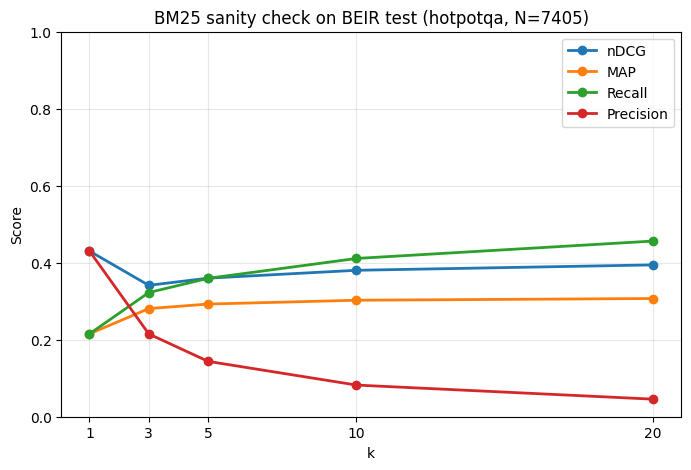

Learned estimator sections below use the same shared BM25 corpus/index/retriever/top-k pipeline, but train on BEIR train and validate on BEIR dev.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

summary_rows = []
for split_name, payload in beir_retrieval.items():
    for metric_name, metric_dict in payload["metrics"].items():
        for k_str, value in metric_dict.items():
            k = int(str(k_str).split("@")[1]) if "@" in str(k_str) else int(k_str)
            summary_rows.append({
                "split": split_name,
                "metric": metric_name,
                "k": k,
                "value": float(value),
            })

beir_metrics_df = pd.DataFrame(summary_rows).sort_values(["split", "metric", "k"]).reset_index(drop=True)
display(
    beir_metrics_df[beir_metrics_df["k"] == 10]
    .pivot(index="split", columns="metric", values="value")
    .sort_index()
)

test_metric_df = beir_metrics_df[beir_metrics_df["split"] == "test"]
plt.figure(figsize=(8, 5))
for metric_name in ["nDCG", "MAP", "Recall", "Precision"]:
    sub = test_metric_df[test_metric_df["metric"] == metric_name]
    plt.plot(sub["k"], sub["value"], marker="o", linewidth=2, label=metric_name)

plt.xticks(sorted(test_metric_df["k"].unique()))
plt.ylim(0, 1)
plt.xlabel("k")
plt.ylabel("Score")
plt.title(f"BM25 sanity check on BEIR test ({BEIR_DATASET}, N={len(beir_test['qids'])})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Learned estimator sections below use the same shared BM25 corpus/index/retriever/top-k pipeline, but train on BEIR train and validate on BEIR dev.")


> Legacy Lucene/Pyserini replication notes were removed from the main notebook body. The thesis-facing workflow below uses the FlashRAG BM25 candidate pool prepared above.


## Main Experiment: Listwise Reranking on Fixed BM25 Candidates

This section is the main estimator-comparison experiment. It keeps retrieval fixed, trains on **BEIR train**, and reports validation curves on **BEIR dev** while keeping **BEIR test** for fixed-BM25 sanity checks only.

Suggested advisor-facing reading order:
1. Retrieval setup and BM25 sanity check above.
2. Estimator definitions and shared candidate-generation contract.
3. Gradient variance and compute plots.
4. Budgeted learning curves and validation efficiency summaries.
5. Toy setwise section at the end, if you want the set-selection extension.


In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

EXPERIMENT_TRACK = "richer_feature_estimator_benchmark"
VALID_EXPERIMENT_TRACKS = {
    "richer_feature_estimator_benchmark",
    "bm25_shortlist_demo",
}
assert EXPERIMENT_TRACK in VALID_EXPERIMENT_TRACKS

TRACK_TITLE_MAP = {
    "richer_feature_estimator_benchmark": "Richer-Feature Estimator Benchmark",
    "bm25_shortlist_demo": "BM25 Shortlist Demo",
}

RERANK_TOP_M = 20
RERANK_K = 10
RERANK_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RERANK_SEED = 7


def tokenize_text(text):
    return re.findall(r"[a-z0-9]+", str(text).lower())


def safe_doc_text(doc):
    title = str(doc.get("title", "") or "")
    contents = str(doc.get("contents", doc.get("text", "")) or "")
    return title, contents


def build_bm25_demo_features(scores, mask):
    safe_scores = torch.where(mask, scores, torch.zeros_like(scores))
    valid_scores = scores[mask]
    global_mean = valid_scores.mean()
    global_std = valid_scores.std().clamp_min(1e-6)
    normalized_bm25 = (safe_scores - global_mean) / global_std
    rank_positions = torch.arange(scores.shape[1], device=scores.device, dtype=scores.dtype).unsqueeze(0).expand_as(scores)
    reciprocal_rank = 1.0 / (rank_positions + 1.0)
    features = torch.stack([normalized_bm25, reciprocal_rank], dim=-1)
    features = features * mask.unsqueeze(-1)
    return features.to(dtype=torch.float64), ["normalized_bm25", "reciprocal_rank"]


def build_richer_rank_features(
    scores,
    mask,
    query_length,
    title_length,
    content_length,
    overlap_count,
    overlap_ratio,
    title_overlap,
):
    safe_scores = torch.where(mask, scores, torch.zeros_like(scores))
    mask_f = mask.to(dtype=scores.dtype)
    rank_positions = torch.arange(scores.shape[1], device=scores.device, dtype=scores.dtype).unsqueeze(0).expand_as(scores)
    reciprocal_rank = 1.0 / (rank_positions + 1.0)

    valid_scores = scores[mask]
    global_mean = valid_scores.mean()
    global_std = valid_scores.std().clamp_min(1e-6)
    normalized_bm25 = (safe_scores - global_mean) / global_std

    query_count = mask_f.sum(dim=1, keepdim=True).clamp_min(1.0)
    query_mean = (safe_scores * mask_f).sum(dim=1, keepdim=True) / query_count
    centered_scores = safe_scores - query_mean
    query_var = ((centered_scores.pow(2) * mask_f).sum(dim=1, keepdim=True) / query_count).clamp_min(1e-12)
    query_std = query_var.sqrt().clamp_min(1e-6)
    query_zscore = centered_scores / query_std

    query_min = scores.masked_fill(~mask, float("inf")).min(dim=1, keepdim=True).values
    query_max = scores.masked_fill(~mask, float("-inf")).max(dim=1, keepdim=True).values
    query_range = (query_max - query_min).clamp_min(1e-6)
    query_minmax = (safe_scores - query_min) / query_range

    top1_score = query_max
    gap_to_top1 = top1_score - safe_scores

    prev_scores = torch.cat([safe_scores[:, :1], safe_scores[:, :-1]], dim=1)
    next_scores = torch.cat([safe_scores[:, 1:], safe_scores[:, -1:]], dim=1)
    gap_to_prev = prev_scores - safe_scores
    gap_to_prev[:, 0] = 0.0
    gap_to_next = safe_scores - next_scores
    gap_to_next[:, -1] = 0.0

    top1_bucket = (rank_positions < 1).to(scores.dtype)
    top3_bucket = (rank_positions < 3).to(scores.dtype)
    top5_bucket = (rank_positions < 5).to(scores.dtype)
    top10_bucket = (rank_positions < 10).to(scores.dtype)

    candidate_list_length = query_count.expand_as(scores)
    availability = mask_f
    interaction = normalized_bm25 * reciprocal_rank

    features = torch.stack(
        [
            normalized_bm25,
            safe_scores,
            rank_positions,
            reciprocal_rank,
            gap_to_top1,
            gap_to_prev,
            gap_to_next,
            query_zscore,
            query_minmax,
            top1_bucket,
            top3_bucket,
            top5_bucket,
            top10_bucket,
            candidate_list_length,
            availability,
            interaction,
            query_length,
            title_length,
            content_length,
            overlap_count,
            overlap_ratio,
            title_overlap,
        ],
        dim=-1,
    )
    features = features * mask.unsqueeze(-1)
    feature_names = [
        "normalized_bm25",
        "raw_bm25",
        "rank_position",
        "reciprocal_rank",
        "gap_to_top1",
        "gap_to_prev",
        "gap_to_next",
        "query_zscore",
        "query_minmax",
        "top1_bucket",
        "top3_bucket",
        "top5_bucket",
        "top10_bucket",
        "candidate_list_length",
        "availability",
        "bm25_times_reciprocal_rank",
        "query_token_length",
        "title_token_length",
        "content_token_length",
        "lexical_overlap_count",
        "lexical_overlap_ratio",
        "title_overlap_flag",
    ]
    return features.to(dtype=torch.float64), feature_names


def build_rank_dataset(
    qids,
    queries_dict,
    qrels_subset,
    retrieved_docs,
    retrieved_scores,
    *,
    top_m=RERANK_TOP_M,
    require_relevant_candidate=True,
):
    candidate_doc_ids = []
    candidate_doc_titles = []
    candidate_doc_texts = []
    candidate_scores_rows = []
    candidate_labels_rows = []
    candidate_mask_rows = []
    candidate_query_length_rows = []
    candidate_title_length_rows = []
    candidate_content_length_rows = []
    candidate_overlap_count_rows = []
    candidate_overlap_ratio_rows = []
    candidate_title_overlap_rows = []
    active_qids = []

    qrels_subset = qrels_subset or {}

    for qid, docs, scores in zip(qids, retrieved_docs, retrieved_scores):
        docs = list(docs[:top_m])
        scores = [float(score) for score in list(scores[:top_m])]
        query_tokens = tokenize_text(queries_dict[qid])
        query_token_set = set(query_tokens)
        query_length = float(len(query_tokens))

        doc_ids = []
        doc_titles = []
        doc_texts = []
        labels = []
        title_lengths = []
        content_lengths = []
        overlap_counts = []
        overlap_ratios = []
        title_overlaps = []
        query_lengths = []

        for doc in docs:
            doc_id = str(doc["id"])
            title, contents = safe_doc_text(doc)
            text_tokens = tokenize_text(contents)
            title_tokens = tokenize_text(title)
            doc_token_set = set(title_tokens) | set(text_tokens)
            overlap = float(len(query_token_set & doc_token_set))
            title_overlap = float(len(query_token_set & set(title_tokens)) > 0)

            doc_ids.append(doc_id)
            doc_titles.append(title)
            doc_texts.append(f"{title}\n{contents}".strip())
            labels.append(float(qrels_subset.get(qid, {}).get(doc_id, 0.0)))
            title_lengths.append(float(len(title_tokens)))
            content_lengths.append(float(len(text_tokens)))
            overlap_counts.append(overlap)
            overlap_ratios.append(overlap / max(len(query_token_set), 1))
            title_overlaps.append(title_overlap)
            query_lengths.append(query_length)

        pad = top_m - len(doc_ids)
        if pad > 0:
            doc_ids.extend([f"__pad__{qid}_{idx}" for idx in range(pad)])
            doc_titles.extend([""] * pad)
            doc_texts.extend([""] * pad)
            scores.extend([-1e9] * pad)
            labels.extend([0.0] * pad)
            title_lengths.extend([0.0] * pad)
            content_lengths.extend([0.0] * pad)
            overlap_counts.extend([0.0] * pad)
            overlap_ratios.extend([0.0] * pad)
            title_overlaps.extend([0.0] * pad)
            query_lengths.extend([query_length] * pad)
            mask = [1.0] * (top_m - pad) + [0.0] * pad
        else:
            mask = [1.0] * top_m

        candidate_doc_ids.append(doc_ids)
        candidate_doc_titles.append(doc_titles)
        candidate_doc_texts.append(doc_texts)
        candidate_scores_rows.append(scores)
        candidate_labels_rows.append(labels)
        candidate_mask_rows.append(mask)
        candidate_query_length_rows.append(query_lengths)
        candidate_title_length_rows.append(title_lengths)
        candidate_content_length_rows.append(content_lengths)
        candidate_overlap_count_rows.append(overlap_counts)
        candidate_overlap_ratio_rows.append(overlap_ratios)
        candidate_title_overlap_rows.append(title_overlaps)
        active_qids.append(qid)

    candidate_scores = torch.tensor(candidate_scores_rows, dtype=torch.float32)
    candidate_labels = torch.tensor(candidate_labels_rows, dtype=torch.float32)
    candidate_mask = torch.tensor(candidate_mask_rows, dtype=torch.bool)
    candidate_query_length = torch.tensor(candidate_query_length_rows, dtype=torch.float32)
    candidate_title_length = torch.tensor(candidate_title_length_rows, dtype=torch.float32)
    candidate_content_length = torch.tensor(candidate_content_length_rows, dtype=torch.float32)
    candidate_overlap_count = torch.tensor(candidate_overlap_count_rows, dtype=torch.float32)
    candidate_overlap_ratio = torch.tensor(candidate_overlap_ratio_rows, dtype=torch.float32)
    candidate_title_overlap = torch.tensor(candidate_title_overlap_rows, dtype=torch.float32)

    if require_relevant_candidate:
        keep_idx = (candidate_labels > 0).any(dim=1).nonzero(as_tuple=False).squeeze(-1)
    else:
        keep_idx = torch.arange(candidate_scores.shape[0])

    rank_qids = [active_qids[idx] for idx in keep_idx.tolist()]
    rank_doc_ids = [candidate_doc_ids[idx] for idx in keep_idx.tolist()]
    rank_doc_titles = [candidate_doc_titles[idx] for idx in keep_idx.tolist()]
    rank_doc_texts = [candidate_doc_texts[idx] for idx in keep_idx.tolist()]
    rank_labels = candidate_labels[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_scores = candidate_scores[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_mask = candidate_mask[keep_idx].to(RERANK_DEVICE)
    rank_query_length = candidate_query_length[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_title_length = candidate_title_length[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_content_length = candidate_content_length[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_overlap_count = candidate_overlap_count[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_overlap_ratio = candidate_overlap_ratio[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)
    rank_title_overlap = candidate_title_overlap[keep_idx].to(RERANK_DEVICE, dtype=torch.float64)

    bm25_demo_features, bm25_demo_feature_names = build_bm25_demo_features(rank_scores, rank_mask)
    richer_benchmark_features, richer_benchmark_feature_names = build_richer_rank_features(
        rank_scores,
        rank_mask,
        rank_query_length,
        rank_title_length,
        rank_content_length,
        rank_overlap_count,
        rank_overlap_ratio,
        rank_title_overlap,
    )

    return {
        "qids": rank_qids,
        "doc_ids": rank_doc_ids,
        "doc_titles": rank_doc_titles,
        "doc_texts": rank_doc_texts,
        "labels": rank_labels,
        "scores": rank_scores,
        "mask": rank_mask,
        "features_by_track": {
            "richer_feature_estimator_benchmark": richer_benchmark_features,
            "bm25_shortlist_demo": bm25_demo_features,
        },
        "feature_names_by_track": {
            "richer_feature_estimator_benchmark": richer_benchmark_feature_names,
            "bm25_shortlist_demo": bm25_demo_feature_names,
        },
    }


torch.manual_seed(RERANK_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RERANK_SEED)

train_rank_data = build_rank_dataset(
    beir_retrieval["train"]["qids"],
    beir_train["queries_dict"],
    beir_train["qrels_subset"],
    beir_retrieval["train"]["docs"],
    beir_retrieval["train"]["scores"],
    top_m=RERANK_TOP_M,
    require_relevant_candidate=True,
)
dev_rank_data = build_rank_dataset(
    beir_retrieval["dev"]["qids"],
    beir_dev["queries_dict"],
    beir_dev["qrels_subset"],
    beir_retrieval["dev"]["docs"],
    beir_retrieval["dev"]["scores"],
    top_m=RERANK_TOP_M,
    require_relevant_candidate=True,
)
test_rank_data = build_rank_dataset(
    beir_retrieval["test"]["qids"],
    beir_test["queries_dict"],
    beir_test["qrels_subset"],
    beir_retrieval["test"]["docs"],
    beir_retrieval["test"]["scores"],
    top_m=RERANK_TOP_M,
    require_relevant_candidate=True,
)

rank_features = train_rank_data["features_by_track"][EXPERIMENT_TRACK]
rank_feature_names = train_rank_data["feature_names_by_track"][EXPERIMENT_TRACK]
rank_qids = train_rank_data["qids"]
rank_doc_ids = train_rank_data["doc_ids"]
rank_labels = train_rank_data["labels"]
rank_scores = train_rank_data["scores"]
rank_mask = train_rank_data["mask"]

dev_rank_features = dev_rank_data["features_by_track"][EXPERIMENT_TRACK]
dev_rank_feature_names = dev_rank_data["feature_names_by_track"][EXPERIMENT_TRACK]
dev_rank_qids = dev_rank_data["qids"]
dev_rank_doc_ids = dev_rank_data["doc_ids"]
dev_rank_labels = dev_rank_data["labels"]
dev_rank_scores = dev_rank_data["scores"]
dev_rank_mask = dev_rank_data["mask"]

test_rank_features = test_rank_data["features_by_track"][EXPERIMENT_TRACK]
test_rank_qids = test_rank_data["qids"]
test_rank_doc_ids = test_rank_data["doc_ids"]
test_rank_labels = test_rank_data["labels"]
test_rank_scores = test_rank_data["scores"]
test_rank_mask = test_rank_data["mask"]

bm25_demo_feature_names = train_rank_data["feature_names_by_track"]["bm25_shortlist_demo"]
richer_benchmark_feature_names = train_rank_data["feature_names_by_track"]["richer_feature_estimator_benchmark"]
EXPERIMENT_TRACK_LABEL = TRACK_TITLE_MAP[EXPERIMENT_TRACK]

print(f"Experiment track: {EXPERIMENT_TRACK_LABEL} ({EXPERIMENT_TRACK})")
print("Candidate-generation contract: same corpus, same BM25 index, same retriever config, same retrieval_topk, same top-M truncation, same feature construction; only the query split differs.")
print(f"Train queries with at least one relevant candidate in top-{RERANK_TOP_M}: {len(rank_qids)} / {len(beir_retrieval['train']['qids'])}")
print(f"Dev queries with at least one relevant candidate in top-{RERANK_TOP_M}: {len(dev_rank_qids)} / {len(beir_retrieval['dev']['qids'])}")
print(f"Test queries with at least one relevant candidate in top-{RERANK_TOP_M}: {len(test_rank_qids)} / {len(beir_retrieval['test']['qids'])}")
print("train rank_scores shape:", tuple(rank_scores.shape))
print("dev rank_scores shape:", tuple(dev_rank_scores.shape))
print("selected train rank_features shape:", tuple(rank_features.shape))
print("Using device:", RERANK_DEVICE)

display(pd.DataFrame({
    "track": ["bm25_shortlist_demo", "richer_feature_estimator_benchmark"],
    "feature_dim": [len(bm25_demo_feature_names), len(richer_benchmark_feature_names)],
}))

display(pd.DataFrame({
    "feature_name": richer_benchmark_feature_names,
    "track": ["richer_feature_estimator_benchmark"] * len(richer_benchmark_feature_names),
}))

sample_idx = 0
print("\nSample active BEIR train query:")
print(rank_qids[sample_idx], beir_train["queries_dict"][rank_qids[sample_idx]])
print("Top candidate ids:", rank_doc_ids[sample_idx][:10])
print("Top candidate labels:", rank_labels[sample_idx, :10].detach().cpu().tolist())
print("Top candidate BM25 scores:", rank_scores[sample_idx, :10].detach().cpu().tolist())
print("Selected feature names:", rank_feature_names)


Experiment track: Richer-Feature Estimator Benchmark (richer_feature_estimator_benchmark)
Candidate-generation contract: same corpus, same BM25 index, same retriever config, same retrieval_topk, same top-M truncation, same feature construction; only the query split differs.
Train queries with at least one relevant candidate in top-20: 63057 / 85000
Dev queries with at least one relevant candidate in top-20: 4036 / 5447
Test queries with at least one relevant candidate in top-20: 5314 / 7405
train rank_scores shape: (63057, 20)
dev rank_scores shape: (4036, 20)
selected train rank_features shape: (63057, 20, 22)
Using device: cuda


,track,feature_dim
0,bm25_shortlist_demo,2
1,richer_feature_estimator_benchmark,22


,feature_name,track
0,normalized_bm25,richer_feature_estimator_benchmark
1,raw_bm25,richer_feature_estimator_benchmark
2,rank_position,richer_feature_estimator_benchmark
3,reciprocal_rank,richer_feature_estimator_benchmark
4,gap_to_top1,richer_feature_estimator_benchmark
5,gap_to_prev,richer_feature_estimator_benchmark
6,gap_to_next,richer_feature_estimator_benchmark
7,query_zscore,richer_feature_estimator_benchmark
8,query_minmax,richer_feature_estimator_benchmark
9,top1_bucket,richer_feature_estimator_benchmark



Sample active BEIR train query:
5ac0d92f554299012d1db645 How many fountains where present "World of Color" which includes lights,fire,laser and fog which has anthology television series and created by Steve Davison, who is Lead Creative Executive of Parades for Walt Disney and author such a shows as "Believe..There's Magic in the Start", "Disney Dreams!"?
Top candidate ids: ['35694141', '12775381', '53998544', '3004624', '15894467', '1188373', '2398591', '46350968', '1398653', '21038594']
Top candidate labels: [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Top candidate BM25 scores: [27.87796401977539, 26.625755310058594, 22.741018295288086, 20.865461349487305, 19.616825103759766, 19.577239990234375, 19.430566787719727, 19.296310424804688, 19.200035095214844, 19.178279876708984]
Selected feature names: ['normalized_bm25', 'raw_bm25', 'rank_position', 'reciprocal_rank', 'gap_to_top1', 'gap_to_prev', 'gap_to_next', 'query_zscore', 'query_minmax', 'top1_bucket', 'top3_bucket', 'top5_

In [13]:
def _discounts(k, device, dtype=torch.float32):
    return 1.0 / torch.log2(torch.arange(2, k + 2, device=device, dtype=dtype))


def dcg_at_k_from_ranked_labels(ranked_labels, k):
    ranked_labels = ranked_labels[..., :k]
    discounts = _discounts(k, ranked_labels.device, ranked_labels.dtype)
    return (ranked_labels * discounts).sum(dim=-1)


def ideal_dcg_at_k(labels, k):
    ideal_ranked = torch.sort(labels, dim=-1, descending=True).values[..., :k]
    discounts = _discounts(k, labels.device, labels.dtype)
    return (ideal_ranked * discounts).sum(dim=-1)


def ndcg_at_k_from_ranked_labels(ranked_labels, full_labels, k):
    dcg = dcg_at_k_from_ranked_labels(ranked_labels, k)
    idcg = ideal_dcg_at_k(full_labels, k)
    while idcg.ndim < dcg.ndim:
        idcg = idcg.unsqueeze(-1)
    zeros = torch.zeros_like(dcg)
    return torch.where(idcg > 0, dcg / idcg, zeros)


def ndcg_rank_weights(labels, k):
    cutoff = min(k, labels.shape[-1])
    discounts = _discounts(cutoff, labels.device, labels.dtype).unsqueeze(0).expand(labels.shape[0], -1)
    idcg = ideal_dcg_at_k(labels, cutoff).unsqueeze(-1)
    safe_idcg = idcg.clamp_min(1e-8)
    zeros = torch.zeros_like(discounts)
    return torch.where(idcg > 0, discounts / safe_idcg, zeros)


def gather_ranked_labels(labels, rankings):
    expanded_labels = labels[:, None, :].expand(-1, rankings.shape[1], -1)
    return torch.gather(expanded_labels, 2, rankings)


def sampled_ndcg(rankings, labels, k):
    ranked_labels = gather_ranked_labels(labels, rankings)
    return ndcg_at_k_from_ranked_labels(ranked_labels, labels, k)


def greedy_rankings_from_scores(scores, mask, topk):
    masked_scores = scores.masked_fill(~mask, float("-inf"))
    return torch.argsort(masked_scores, dim=-1, descending=True)[..., :topk]


def greedy_ndcg(scores, labels, mask, k):
    greedy_rankings = greedy_rankings_from_scores(scores, mask, k)
    ranked_labels = torch.gather(labels, 1, greedy_rankings)
    return ndcg_at_k_from_ranked_labels(ranked_labels, labels, k)


baseline_greedy_ndcg = greedy_ndcg(rank_scores, rank_labels, rank_mask, RERANK_K)
print(f"Mean greedy nDCG@{RERANK_K} from raw BM25 candidate scores: {baseline_greedy_ndcg.mean().item():.4f}")
print("Sample greedy labels:", torch.gather(rank_labels[:1], 1, greedy_rankings_from_scores(rank_scores[:1], rank_mask[:1], RERANK_K)).squeeze(0).detach().cpu().tolist())


Mean greedy nDCG@10 from raw BM25 candidate scores: 0.7477
Sample greedy labels: [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [14]:
RERANK_MODEL_PARAMS_BY_TRACK = {
    "bm25_shortlist_demo": {
        "hidden_units": [32, 16],
        "activation": "sigmoid",
    },
    "richer_feature_estimator_benchmark": {
        "hidden_units": [64, 32],
        "activation": "relu",
    },
}


def build_activation(name):
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unknown activation: {name}")


class NeuralReranker(nn.Module):
    def __init__(self, feature_dim, model_params=None, dtype=torch.float64):
        super().__init__()
        hidden_units = model_params.get("hidden_units", [])
        activation_name = model_params.get("activation", "relu")

        layers = []
        in_dim = feature_dim
        for hidden_dim in hidden_units:
            layers.append(nn.Linear(in_dim, hidden_dim, dtype=dtype))
            layers.append(build_activation(activation_name))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, 1, dtype=dtype))

        self.scorer = nn.Sequential(*layers)
        self.output_dtype = dtype
        self.model_params = model_params

    def forward(self, features, mask):
        scores = self.scorer(features.to(self.output_dtype)).squeeze(-1)
        return scores.masked_fill(~mask, float("-inf"))


def make_ranker(seed=RERANK_SEED, feature_dim=None, model_params=None, track_identifier=None):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    track_identifier = EXPERIMENT_TRACK if track_identifier is None else track_identifier
    params = RERANK_MODEL_PARAMS_BY_TRACK[track_identifier] if model_params is None else model_params
    feature_dim = rank_features.shape[-1] if feature_dim is None else feature_dim
    return NeuralReranker(
        feature_dim,
        model_params=params,
    ).to(RERANK_DEVICE)


# Keep the main Plackett-Luce estimators separate from the scalar-reward
# baselines so the thesis-facing comparison stays easy to read.
def dcg_rank_weights(k, device, dtype=torch.float32):
    return _discounts(int(k), device, dtype)


def sampled_dcg(rankings, labels, k):
    ranked_labels = gather_ranked_labels(labels, rankings)
    return dcg_at_k_from_ranked_labels(ranked_labels, k)


def sampled_reward(rankings, labels, k, reward_type="ndcg"):
    if reward_type == "ndcg":
        return sampled_ndcg(rankings, labels, k)
    if reward_type == "dcg":
        return sampled_dcg(rankings, labels, k)
    raise ValueError(f"Unknown reward_type: {reward_type}")


def greedy_dcg(scores, labels, mask, k):
    greedy_rankings = greedy_rankings_from_scores(scores, mask, k)
    ranked_labels = torch.gather(labels, 1, greedy_rankings)
    return dcg_at_k_from_ranked_labels(ranked_labels, k)


def pl_log_probs_for_rankings(logits, rankings, mask):
    batch_size, n_samples, topk = rankings.shape
    expanded_logits = logits[:, None, :].expand(-1, n_samples, -1)
    available = mask[:, None, :].expand(-1, n_samples, -1).clone()
    step_log_probs = []

    for pos in range(topk):
        masked_logits = expanded_logits.masked_fill(~available, float("-inf"))
        step_log_all = F.log_softmax(masked_logits, dim=-1)
        chosen = rankings[:, :, pos]
        chosen_log_prob = torch.gather(step_log_all, 2, chosen.unsqueeze(-1)).squeeze(-1)
        step_log_probs.append(chosen_log_prob)
        available.scatter_(2, chosen.unsqueeze(-1), False)

    return torch.stack(step_log_probs, dim=-1)


def pl_probabilities_for_rankings(logits, rankings, mask):
    batch_size, n_samples, topk = rankings.shape
    expanded_logits = logits[:, None, :].expand(-1, n_samples, -1)
    available = mask[:, None, :].expand(-1, n_samples, -1).clone()
    prob_per_rank = []

    for pos in range(topk):
        masked_logits = expanded_logits.masked_fill(~available, float("-inf"))
        step_probs = F.softmax(masked_logits, dim=-1)
        prob_per_rank.append(step_probs)
        chosen = rankings[:, :, pos]
        available.scatter_(2, chosen.unsqueeze(-1), False)

    return torch.stack(prob_per_rank, dim=2)


def sample_rankings_sequential(logits, mask, n_samples, topk):
    batch_size, n_docs = logits.shape
    expanded_logits = logits[:, None, :].expand(-1, n_samples, -1)
    available = mask[:, None, :].expand(-1, n_samples, -1).clone()
    rankings = []
    step_log_probs = []

    for _ in range(topk):
        masked_logits = expanded_logits.masked_fill(~available, float("-inf"))
        flat_probs = F.softmax(masked_logits, dim=-1).reshape(batch_size * n_samples, n_docs)
        chosen = torch.multinomial(flat_probs, num_samples=1).reshape(batch_size, n_samples)
        chosen_prob = torch.gather(flat_probs, 1, chosen.reshape(-1, 1)).reshape(batch_size, n_samples)
        rankings.append(chosen)
        step_log_probs.append(chosen_prob.clamp_min(1e-12).log())
        available.scatter_(2, chosen.unsqueeze(-1), False)

    return torch.stack(rankings, dim=-1), torch.stack(step_log_probs, dim=-1)


def sample_rankings_pl_gumbel(logits, mask, n_samples, topk):
    batch_size, n_docs = logits.shape
    expanded_logits = logits[:, None, :].expand(-1, n_samples, -1)
    masked_logits = expanded_logits.masked_fill(~mask[:, None, :], float("-inf"))

    # PL-Rank samples rankings with Gumbel perturb-and-sort under the PL model.
    uniform = torch.rand(batch_size, n_samples, n_docs, device=logits.device, dtype=logits.dtype).clamp_(1e-12, 1 - 1e-12)
    gumbel_noise = -torch.log(-torch.log(uniform))
    rankings = torch.argsort(masked_logits + gumbel_noise, dim=-1, descending=True)[..., :topk]
    step_log_probs = pl_log_probs_for_rankings(logits, rankings, mask)
    return rankings, step_log_probs


def sample_rankings_retrieval2_gumbel(logits, mask, n_samples, topk, tau=1.0, hard=False):
    batch_size, n_docs = logits.shape
    expanded_logits = logits[:, None, :].expand(-1, n_samples, -1)
    masked_logits = expanded_logits.masked_fill(~mask[:, None, :], torch.finfo(logits.dtype).min)

    # Scalar-reward PG baselines use gumbel_softmax, argsort, then gather the
    # base log-softmax terms in the sampled order.
    base_log_probs = F.log_softmax(masked_logits, dim=-1)
    sample_probs = F.gumbel_softmax(base_log_probs, tau=tau, hard=hard, dim=-1)
    rankings = torch.argsort(sample_probs, dim=-1, descending=True)[..., :topk]
    gathered_log_probs = torch.gather(base_log_probs, 2, rankings)
    return rankings, gathered_log_probs


def sample_rankings_gumbel_softmax(logits, mask, n_samples, topk, tau=1.0, hard=False):
    return sample_rankings_retrieval2_gumbel(logits, mask, n_samples=n_samples, topk=topk, tau=tau, hard=hard)


def sample_rankings_gumbel_sort(logits, mask, n_samples, topk, tau=1.0):
    if tau != 1.0:
        raise ValueError("`tau` is not part of the PL Gumbel sampler; keep it at 1.0.")
    return sample_rankings_pl_gumbel(logits, mask, n_samples=n_samples, topk=topk)


def sample_rankings(logits, mask, n_samples, topk, sampler="sequential", tau=1.0):
    if sampler == "sequential":
        return sample_rankings_sequential(logits, mask, n_samples=n_samples, topk=topk)
    if sampler in {"pl_gumbel", "gumbel_sort"}:
        return sample_rankings_pl_gumbel(logits, mask, n_samples=n_samples, topk=topk)
    if sampler in {"retrieval2_gumbel", "gumbel"}:
        return sample_rankings_retrieval2_gumbel(logits, mask, n_samples=n_samples, topk=topk, tau=tau)
    raise ValueError(f"Unknown sampler: {sampler}")


def compute_rloo_baseline(rewards):
    if rewards.shape[1] <= 1:
        return torch.zeros_like(rewards)
    return (rewards.sum(dim=1, keepdim=True) - rewards) / (rewards.shape[1] - 1)


def compute_batch_mean_baseline(rewards):
    return torch.full_like(rewards, rewards.mean())


def retrieval2_entropy(log_probs):
    safe_log_probs = torch.clamp(log_probs, min=torch.finfo(log_probs.dtype).min)
    probs = safe_log_probs.exp()
    return -(safe_log_probs * probs).sum(dim=-1)


def sample_rankings_retrieval2_full(logits, mask, n_samples, tau=1.0, hard=False):
    batch_size, n_docs = logits.shape
    masked_logits = logits.masked_fill(~mask, torch.finfo(logits.dtype).min)
    base_log_probs = F.log_softmax(masked_logits, dim=-1)
    entropy = retrieval2_entropy(base_log_probs)

    repeated_log_probs = torch.repeat_interleave(base_log_probs, n_samples, dim=0)
    probs = F.gumbel_softmax(repeated_log_probs, tau=tau, hard=hard, dim=-1)
    full_rankings = torch.argsort(probs, dim=-1, descending=True)
    gathered_log_probs = torch.gather(repeated_log_probs, 1, full_rankings)

    return (
        full_rankings.reshape(batch_size, n_samples, n_docs),
        gathered_log_probs.reshape(batch_size, n_samples, n_docs),
        entropy,
    )


def retrieval2_subranking_rewards(full_rankings, labels, topk, reward_type="ndcg"):
    batch_size, n_samples, n_docs = full_rankings.shape
    flat_rankings = full_rankings.reshape(batch_size * n_samples, n_docs)
    true_rel = torch.repeat_interleave(labels, n_samples, dim=0)
    predicted_rel = torch.gather(true_rel, 1, flat_rankings)
    true_rel = torch.sort(true_rel, dim=1, descending=True)[0]

    top_k_mask = torch.zeros_like(predicted_rel)
    top_k_mask[:, :topk] = 1

    order_ = torch.repeat_interleave(
        torch.arange(1, predicted_rel.shape[1] + 1, device=predicted_rel.device)[None, :],
        predicted_rel.shape[0],
        dim=0,
    )
    map_ = predicted_rel * top_k_mask
    map_ = map_ * order_
    map_ = map_.to(torch.float64)
    map_[map_ > 0] = 1.0 / map_[map_ > 0]
    map_ = map_ / true_rel.sum(dim=1, keepdim=True).clamp_min(1)
    map_ = map_ + torch.sum(map_, dim=-1, keepdim=True) - torch.cumsum(map_, dim=-1)

    dcg_rank = torch.repeat_interleave(
        torch.arange(1, predicted_rel.shape[1] + 1, device=predicted_rel.device)[None, :],
        predicted_rel.shape[0],
        dim=0,
    )

    true_rel = true_rel * top_k_mask
    predicted_rel = predicted_rel * true_rel

    dcg = predicted_rel / torch.log2(dcg_rank + 1)
    idcg = true_rel / torch.log2(dcg_rank + 1)
    dcg = dcg + torch.sum(dcg, dim=-1, keepdim=True) - torch.cumsum(dcg, dim=-1)
    idcg = idcg + torch.sum(idcg, dim=-1, keepdim=True) - torch.cumsum(idcg, dim=-1)

    ndcg = torch.zeros_like(dcg)
    valid = idcg > 0
    ndcg[valid] = dcg[valid] / idcg[valid]

    if reward_type.lower() == "ndcg":
        rewards = ndcg
    elif reward_type.lower() == "map":
        rewards = map_
    else:
        raise NotImplementedError(f"retrieval2 reward_type={reward_type!r} is not implemented")

    return {
        "rewards": rewards.reshape(batch_size, n_samples, n_docs),
        "dcg": dcg.reshape(batch_size, n_samples, n_docs),
        "idcg": idcg.reshape(batch_size, n_samples, n_docs),
        "map": map_.reshape(batch_size, n_samples, n_docs),
        "ndcg": ndcg.reshape(batch_size, n_samples, n_docs),
        "true_rel": true_rel.reshape(batch_size, n_samples, n_docs),
    }


def paper_pg_rank_scalar_reward(full_rankings, labels, topk, reward_type="ndcg"):
    if reward_type.lower() != "ndcg":
        raise NotImplementedError("Paper-faithful PG-Rank currently supports only scalar nDCG reward.")
    batch_size, n_samples, n_docs = full_rankings.shape
    flat_rankings = full_rankings[:, :, :topk].reshape(batch_size * n_samples, topk)
    repeated_labels = torch.repeat_interleave(labels, n_samples, dim=0)
    ranked_labels = torch.gather(repeated_labels, 1, flat_rankings)
    rewards = ndcg_at_k_from_ranked_labels(ranked_labels, topk)
    return rewards.reshape(batch_size, n_samples)


def paper_leave_one_out_baseline(rewards):
    if rewards.shape[1] <= 1:
        return torch.zeros_like(rewards)
    reward_sums = rewards.sum(dim=1, keepdim=True)
    return (reward_sums - rewards) / (rewards.shape[1] - 1)



def build_metric_info(logits, rankings, labels, mask, topk, objective_rewards, objective_name, extras=None):
    sampled_dcg_values = sampled_dcg(rankings, labels, topk)
    sampled_ndcg_values = sampled_ndcg(rankings, labels, topk)
    info = {
        "rankings": rankings,
        "ranking_rewards": objective_rewards,
        "objective_name": objective_name,
        "mean_reward": float(objective_rewards.mean().item()),
        "mean_sampled_dcg": float(sampled_dcg_values.mean().item()),
        "mean_sampled_ndcg": float(sampled_ndcg_values.mean().item()),
        "greedy_dcg": float(greedy_dcg(logits, labels, mask, topk).mean().item()),
        "greedy_ndcg": float(greedy_ndcg(logits, labels, mask, topk).mean().item()),
    }
    if extras:
        info.update(extras)
    return info


def policy_gradient_loss(
    model,
    features,
    labels,
    mask,
    n_samples,
    topk,
    sampler="sequential",
    tau=1.0,
    reward_type="ndcg",
    baseline_type="none",
):
    logits = model(features, mask)
    rankings, step_log_probs = sample_rankings(
        logits,
        mask,
        n_samples=n_samples,
        topk=topk,
        sampler=sampler,
        tau=tau,
    )
    objective_rewards = sampled_reward(rankings, labels, k=topk, reward_type=reward_type)

    if baseline_type == "none":
        baseline = torch.zeros_like(objective_rewards)
    elif baseline_type == "rloo":
        baseline = compute_rloo_baseline(objective_rewards)
    elif baseline_type == "batch_mean":
        baseline = compute_batch_mean_baseline(objective_rewards)
    else:
        raise ValueError(f"Unknown baseline_type: {baseline_type}")

    advantages = objective_rewards - baseline
    loss = -(step_log_probs.sum(dim=-1) * advantages).mean()

    return loss, build_metric_info(
        logits,
        rankings,
        labels,
        mask,
        topk,
        objective_rewards,
        objective_name=reward_type,
        extras={
            "step_log_probs": step_log_probs,
            "baseline": baseline,
            "advantages": advantages,
            "sampler": sampler,
            "reward_type": reward_type,
        },
    )


def reinforce_loss(
    model,
    features,
    labels,
    mask,
    n_samples,
    topk,
    sampler="sequential",
    tau=1.0,
    baseline_type="none",
    reward_type="ndcg",
):
    return policy_gradient_loss(
        model,
        features,
        labels,
        mask,
        n_samples=n_samples,
        topk=topk,
        sampler=sampler,
        tau=tau,
        reward_type=reward_type,
        baseline_type=baseline_type,
    )


def placement_policy_gradient_loss(model, features, labels, mask, n_samples, topk, sampler="pl_gumbel"):
    logits = model(features, mask)
    rankings, step_log_probs = sample_rankings(
        logits,
        mask,
        n_samples=n_samples,
        topk=topk,
        sampler=sampler,
        tau=1.0,
    )
    rank_weights = dcg_rank_weights(topk, labels.device, labels.dtype)
    ranked_labels = gather_ranked_labels(labels, rankings)[..., :topk]
    reward_matrix = ranked_labels * rank_weights.view(1, 1, -1)
    cumulative_rewards = torch.flip(torch.cumsum(torch.flip(reward_matrix, dims=[-1]), dim=-1), dims=[-1])
    loss = -(step_log_probs * cumulative_rewards).sum(dim=-1).mean()
    objective_rewards = reward_matrix.sum(dim=-1)

    return loss, build_metric_info(
        logits,
        rankings,
        labels,
        mask,
        topk,
        objective_rewards,
        objective_name="dcg",
        extras={
            "step_log_probs": step_log_probs,
            "reward_matrix": reward_matrix,
            "cumulative_rewards": cumulative_rewards,
            "sampler": sampler,
        },
    )


def neural_pg_rank_loss(
    model,
    features,
    labels,
    mask,
    n_samples,
    topk,
    tau=0.05,
    reward_type="ndcg",
    baseline_type="paper_loo",
    reward_setup="subranking",
    entropy_coeff=0.01,
    gumbel_softmax_hard=False,
):
    if reward_setup not in {None, "subranking"}:
        raise NotImplementedError("Neural PG-Rank (Eq. 7) uses subranking returns.")
    if baseline_type not in {"paper_loo", "none"}:
        raise NotImplementedError(f"Neural PG-Rank (Eq. 7) baseline_type={baseline_type!r} is not implemented")
    if reward_type.lower() != "ndcg":
        raise NotImplementedError("Neural PG-Rank (Eq. 7) currently supports only nDCG reward.")

    logits = model(features, mask)
    full_rankings, gathered_log_probs, entropy = sample_rankings_retrieval2_full(
        logits,
        mask,
        n_samples=n_samples,
        tau=tau,
        hard=gumbel_softmax_hard,
    )
    reward_info = retrieval2_subranking_rewards(full_rankings, labels, topk=topk, reward_type=reward_type)
    returns = reward_info["rewards"].clone()
    if baseline_type == "paper_loo":
        baseline = compute_rloo_baseline(returns)
    else:
        baseline = torch.zeros_like(returns)
    advantages = returns - baseline

    policy_loss = -(gathered_log_probs * advantages).mean(dim=1).mean()
    entropy_loss = -entropy.mean()
    loss = policy_loss + entropy_coeff * entropy_loss

    sampled_rankings_topk = full_rankings[..., :topk]
    objective_rewards = reward_info[reward_type.lower()][..., 0]
    return loss, build_metric_info(
        logits,
        sampled_rankings_topk,
        labels,
        mask,
        topk,
        objective_rewards,
        objective_name="eq7_ndcg_subranking",
        extras={
            "sampler": "retrieval2_gumbel",
            "tau": tau,
            "baseline_type": baseline_type,
            "reward_type": reward_type,
            "reward_setup": "subranking",
            "entropy_coeff": entropy_coeff,
            "gumbel_softmax_hard": gumbel_softmax_hard,
            "policy_loss": float(policy_loss.detach().cpu()),
            "entropy_loss": float(entropy_loss.detach().cpu()),
            "advantages": advantages,
            "baseline": baseline,
            "returns": returns,
            "returns_mask": reward_info["true_rel"],
            "full_rankings": full_rankings,
            "eq7_style": True,
        },
    )


def pl_rank_1_score_grads(rank_weights, labels, logits, mask, sampled_rankings):
    cutoff = sampled_rankings.shape[-1]
    n_samples = sampled_rankings.shape[1]
    n_docs = logits.shape[-1]

    ranked_labels = gather_ranked_labels(labels, sampled_rankings)[..., :cutoff]
    if rank_weights.ndim == 1:
        rank_weights_exp = rank_weights.view(1, 1, cutoff)
    else:
        rank_weights_exp = rank_weights.unsqueeze(1)
    weighted_labels = ranked_labels * rank_weights_exp
    cumsum_labels = torch.flip(torch.cumsum(torch.flip(weighted_labels, dims=[-1]), dim=-1), dims=[-1])

    positive_terms = torch.zeros(logits.shape[0], n_samples, n_docs, device=logits.device, dtype=logits.dtype)
    positive_terms.scatter_add_(2, sampled_rankings[..., :cutoff], cumsum_labels)
    positive_terms = positive_terms.mean(dim=1)

    prob_per_rank = pl_probabilities_for_rankings(logits, sampled_rankings, mask)
    negative_terms = (prob_per_rank * cumsum_labels.unsqueeze(-1)).sum(dim=2).mean(dim=1)
    return positive_terms - negative_terms


def pl_rank_2_score_grads(rank_weights, labels, logits, mask, sampled_rankings):
    cutoff = sampled_rankings.shape[-1]
    n_samples = sampled_rankings.shape[1]
    n_docs = logits.shape[-1]

    ranked_labels = gather_ranked_labels(labels, sampled_rankings)[..., :cutoff]
    if rank_weights.ndim == 1:
        rank_weights_exp = rank_weights.view(1, 1, cutoff)
        rank_weights_bonus = rank_weights.view(1, 1, cutoff, 1)
    else:
        rank_weights_exp = rank_weights.unsqueeze(1)
        rank_weights_bonus = rank_weights.unsqueeze(1).unsqueeze(-1)
    weighted_labels = ranked_labels * rank_weights_exp
    cumsum_labels = torch.flip(torch.cumsum(torch.flip(weighted_labels, dims=[-1]), dim=-1), dims=[-1])

    positive_terms = torch.zeros(logits.shape[0], n_samples, n_docs, device=logits.device, dtype=logits.dtype)
    if cutoff > 1:
        positive_terms.scatter_add_(2, sampled_rankings[..., :-1], cumsum_labels[..., 1:])
    positive_terms = positive_terms.mean(dim=1)

    prob_per_rank = pl_probabilities_for_rankings(logits, sampled_rankings, mask)
    negative_terms = (prob_per_rank * cumsum_labels.unsqueeze(-1)).sum(dim=2).mean(dim=1)
    relevant_bonus = (prob_per_rank * rank_weights_bonus).sum(dim=2).mean(dim=1) * labels
    return positive_terms - negative_terms + relevant_bonus


def pl_rank_loss(model, features, labels, mask, n_samples, topk, variant="pl_rank_1", sampler="pl_gumbel", reward_type="dcg"):
    logits = model(features, mask)
    rankings, _ = sample_rankings(logits, mask, n_samples=n_samples, topk=topk, sampler=sampler, tau=1.0)
    if reward_type == "dcg":
        rank_weights = dcg_rank_weights(topk, labels.device, labels.dtype)
        objective_rewards = sampled_dcg(rankings, labels, k=topk)
    elif reward_type == "ndcg":
        rank_weights = ndcg_rank_weights(labels, topk)
        objective_rewards = sampled_ndcg(rankings, labels, k=topk)
    else:
        raise ValueError(f"Unknown PL-Rank reward_type: {reward_type}")

    if variant == "pl_rank_1":
        score_grads = pl_rank_1_score_grads(rank_weights, labels, logits, mask, rankings)
    elif variant == "pl_rank_2":
        score_grads = pl_rank_2_score_grads(rank_weights, labels, logits, mask, rankings)
    else:
        raise ValueError(f"Unknown PL-Rank variant: {variant}")

    safe_logits = torch.where(mask, logits, torch.zeros_like(logits))
    loss = -(safe_logits * score_grads.detach()).sum(dim=-1).mean()

    return loss, build_metric_info(
        logits,
        rankings,
        labels,
        mask,
        topk,
        objective_rewards,
        objective_name=reward_type,
        extras={"score_grads": score_grads, "variant": variant, "sampler": sampler, "reward_type": reward_type},
    )


def pl_rank_1_loss(model, features, labels, mask, n_samples, topk, tau=1.0):
    if tau != 1.0:
        raise ValueError("PL-Rank uses the PL Gumbel sampler without a temperature parameter.")
    return pl_rank_loss(model, features, labels, mask, n_samples=n_samples, topk=topk, variant="pl_rank_1")


def pl_rank_2_loss(model, features, labels, mask, n_samples, topk, tau=1.0):
    if tau != 1.0:
        raise ValueError("PL-Rank uses the PL Gumbel sampler without a temperature parameter.")
    return pl_rank_loss(model, features, labels, mask, n_samples=n_samples, topk=topk, variant="pl_rank_2")


def estimator_loss(
    model,
    features,
    labels,
    mask,
    n_samples,
    topk,
    estimator,
    sampler=None,
    tau=1.0,
    baseline_type="none",
    reward_type=None,
    reward_setup=None,
    entropy_coeff=0.0,
    gumbel_softmax_hard=False,
):
    if estimator == "reinforce":
        return policy_gradient_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            sampler="sequential" if sampler is None else sampler,
            tau=tau,
            reward_type="ndcg" if reward_type is None else reward_type,
            baseline_type=baseline_type,
        )
    if estimator == "policy_gradient":
        return policy_gradient_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            sampler="pl_gumbel" if sampler is None else sampler,
            tau=tau,
            reward_type="ndcg" if reward_type is None else reward_type,
            baseline_type=baseline_type,
        )
    if estimator == "retrieval2_scalar":
        return policy_gradient_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            sampler="retrieval2_gumbel" if sampler is None else sampler,
            tau=tau,
            reward_type="ndcg" if reward_type is None else reward_type,
            baseline_type=baseline_type,
        )
    if estimator == "neural_pg_rank":
        return neural_pg_rank_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            tau=tau,
            reward_type="ndcg" if reward_type is None else reward_type,
            baseline_type=baseline_type,
            reward_setup=reward_setup,
            entropy_coeff=entropy_coeff,
            gumbel_softmax_hard=gumbel_softmax_hard,
        )
    if estimator == "placement_policy_gradient":
        return placement_policy_gradient_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            sampler="pl_gumbel" if sampler is None else sampler,
        )
    if estimator == "pl_rank_1":
        return pl_rank_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            variant="pl_rank_1",
            sampler="pl_gumbel" if sampler is None else sampler,
            reward_type="ndcg" if reward_type is None else reward_type,
        )
    if estimator == "pl_rank_2":
        return pl_rank_loss(
            model,
            features,
            labels,
            mask,
            n_samples=n_samples,
            topk=topk,
            variant="pl_rank_2",
            sampler="pl_gumbel" if sampler is None else sampler,
            reward_type="ndcg" if reward_type is None else reward_type,
        )
    raise ValueError(f"Unknown estimator: {estimator}")


ranker = make_ranker()
print(ranker)


NeuralReranker(
  (scorer): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [15]:
torch.manual_seed(RERANK_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RERANK_SEED)

small_batch = min(8, rank_features.shape[0])
inspect_features = rank_features[:small_batch]
inspect_labels = rank_labels[:small_batch]
inspect_mask = rank_mask[:small_batch]
inspect_qids = rank_qids[:small_batch]
inspect_doc_ids = rank_doc_ids[:small_batch]

smoke_test_configs = [
    ("Sequential REINFORCE (exact PL + nDCG)", dict(estimator="reinforce", sampler="sequential", reward_type="ndcg")),
    ("Naive REINFORCE", dict(estimator="policy_gradient", sampler="sequential", reward_type="dcg")),
    ("Neural PG-Rank (Gumbel-softmax + RLOO)", dict(estimator="neural_pg_rank")),
    ("Oosterhuis PL-Rank", dict(estimator="pl_rank_1")),
    ("Placement PG (Oosterhuis, reference)", dict(estimator="placement_policy_gradient")),
    ("retrieval2 scalar PG", dict(estimator="retrieval2_scalar", sampler="retrieval2_gumbel", reward_type="ndcg")),
    ("PL-Rank-2 (Oosterhuis)", dict(estimator="pl_rank_2")),
]

for label, cfg in smoke_test_configs:
    loss, info = estimator_loss(
        ranker,
        inspect_features,
        inspect_labels,
        inspect_mask,
        n_samples=4,
        topk=RERANK_K,
        tau=1.0,
        baseline_type=cfg.get("baseline_type", "none"),
        reward_type=cfg.get("reward_type"),
        sampler=cfg.get("sampler"),
        estimator=cfg["estimator"],
    )
    print(f"\n=== {label} ===")
    print("Loss:", float(loss.detach().cpu()))
    print(
        f"Objective={info['objective_name']} | mean objective={info['mean_reward']:.4f} | "
        f"mean sampled DCG@{RERANK_K}={info['mean_sampled_dcg']:.4f} | "
        f"mean sampled nDCG@{RERANK_K}={info['mean_sampled_ndcg']:.4f} | "
        f"mean greedy nDCG@{RERANK_K}={info['greedy_ndcg']:.4f}"
    )

with torch.no_grad():
    logits = ranker(inspect_features, inspect_mask)
    greedy_rank = greedy_rankings_from_scores(logits[:1], inspect_mask[:1], RERANK_K)[0].detach().cpu().tolist()
    print("\nGreedy ranking labels:", torch.gather(inspect_labels[0], 0, torch.tensor(greedy_rank, device=inspect_labels.device)).detach().cpu().tolist())


=== Sequential REINFORCE (exact PL + nDCG) ===
Loss: 6.968639319176526
Objective=ndcg | mean objective=0.2571 | mean sampled DCG@10=0.3254 | mean sampled nDCG@10=0.2571 | mean greedy nDCG@10=0.4182

=== Naive REINFORCE ===
Loss: 9.152723946284794
Objective=dcg | mean objective=0.3442 | mean sampled DCG@10=0.3442 | mean sampled nDCG@10=0.2623 | mean greedy nDCG@10=0.4182

=== Neural PG-Rank (Gumbel-softmax + RLOO) ===
Loss: 0.019427786534033126
Objective=eq7_ndcg_subranking | mean objective=0.1321 | mean sampled DCG@10=0.3745 | mean sampled nDCG@10=0.3198 | mean greedy nDCG@10=0.4182

=== Oosterhuis PL-Rank ===
Loss: -0.014365975243933023
Objective=ndcg | mean objective=0.3054 | mean sampled DCG@10=0.3917 | mean sampled nDCG@10=0.3054 | mean greedy nDCG@10=0.4182

=== Placement PG (Oosterhuis, reference) ===
Loss: 5.333268142777064
Objective=dcg | mean objective=0.4512 | mean sampled DCG@10=0.4512 | mean sampled nDCG@10=0.3577 | mean greedy nDCG@10=0.4182

=== retrieval2 scalar PG ===


### Variance and Compute Comparison

This block isolates estimator quality before the full training curves. The goal is to compare gradient variance and per-step compute under a shared reranking policy and shared candidate sets.


In [16]:
def flatten_grads(model):
    flat = []
    for param in model.parameters():
        grad = torch.zeros_like(param) if param.grad is None else param.grad
        flat.append(grad.detach().reshape(-1))
    return torch.cat(flat)


def make_experiment_batch(max_queries=512, query_seed=12345):
    n_total = rank_features.shape[0]
    n = min(max_queries, n_total)

    g = torch.Generator().manual_seed(query_seed)
    idx = torch.randperm(n_total, generator=g)[:n]

    return (
        rank_features[idx],
        rank_labels[idx],
        rank_mask[idx],
        [rank_qids[i] for i in idx.tolist()],
    )


import time


def maybe_sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def gradient_variance_experiment(
    estimator,
    n_samples_grid,
    sampler=None,
    reward_type=None,
    n_trials=128,
    topk=RERANK_K,
    tau=1.0,
    max_queries=512,
    model_seed=RERANK_SEED,
    base_seed=1000,
    query_seed=12345,
    baseline_type="none",
    reward_setup=None,
    entropy_coeff=0.0,
    gumbel_softmax_hard=False,
):
    exp_features, exp_labels, exp_mask, exp_qids = make_experiment_batch(
        max_queries=max_queries,
        query_seed=query_seed,
    )
    rows = []

    # Build once, then reset weights each trial so only estimator noise remains.
    model = make_ranker(seed=model_seed)
    init_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    for n_samples in n_samples_grid:
        trial_grads = []
        objective_means = []
        sampled_dcg_means = []
        sampled_ndcg_means = []
        greedy_dcg_means = []
        greedy_ndcg_means = []
        loss_means = []
        method_times_ms = []
        total_step_times_ms = []

        for trial in range(n_trials):
            model.load_state_dict(init_state)
            model.zero_grad(set_to_none=True)

            seed = base_seed + trial
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            maybe_sync_cuda()
            step_start = time.perf_counter()
            loss, info = estimator_loss(
                model,
                exp_features,
                exp_labels,
                exp_mask,
                n_samples=n_samples,
                topk=topk,
                estimator=estimator,
                sampler=sampler,
                tau=tau,
                baseline_type=baseline_type,
                reward_type=reward_type,
                reward_setup=reward_setup,
                entropy_coeff=entropy_coeff,
                gumbel_softmax_hard=gumbel_softmax_hard,
            )
            maybe_sync_cuda()
            method_time_ms = (time.perf_counter() - step_start) * 1000.0

            loss.backward()
            maybe_sync_cuda()
            total_step_time_ms = (time.perf_counter() - step_start) * 1000.0

            trial_grads.append(flatten_grads(model).detach().cpu())
            objective_means.append(info["mean_reward"])
            sampled_dcg_means.append(info["mean_sampled_dcg"])
            sampled_ndcg_means.append(info["mean_sampled_ndcg"])
            greedy_dcg_means.append(info["greedy_dcg"])
            greedy_ndcg_means.append(info["greedy_ndcg"])
            loss_means.append(float(loss.detach().cpu()))
            method_times_ms.append(method_time_ms)
            total_step_times_ms.append(total_step_time_ms)

        grad_matrix = torch.stack(trial_grads)
        grad_var = grad_matrix.var(dim=0, unbiased=False)

        rows.append({
            "estimator_key": estimator,
            "sampler": "default" if sampler is None else sampler,
            "baseline_type": baseline_type,
            "objective_name": info["objective_name"],
            "n_samples": n_samples,
            "n_trials": n_trials,
            "n_queries": len(exp_qids),
            "query_seed": query_seed,
            "mean_grad_variance": grad_var.mean().item(),
            "max_grad_variance": grad_var.max().item(),
            "mean_reward": float(np.mean(objective_means)),
            "std_reward": float(np.std(objective_means)),
            "mean_sampled_dcg": float(np.mean(sampled_dcg_means)),
            "mean_sampled_ndcg": float(np.mean(sampled_ndcg_means)),
            "mean_greedy_dcg": float(np.mean(greedy_dcg_means)),
            "mean_greedy_ndcg": float(np.mean(greedy_ndcg_means)),
            "mean_loss": float(np.mean(loss_means)),
            "mean_method_time_ms": float(np.mean(method_times_ms)),
            "mean_total_step_time_ms": float(np.mean(total_step_times_ms)),
        })

    return pd.DataFrame(rows)


N_SAMPLES_GRID = [1, 2, 4, 8, 16, 32, 64, 128]
VARIANCE_TRIALS = 200
VARIANCE_MAX_QUERIES = 512
VARIANCE_QUERY_SEED = 12345
SHOW_PL_RANK_2_IN_MAIN_PLOTS = False

# Main thesis-facing family: unbiased PL estimators and their policy-gradient baselines.
# Main comparison: Naive REINFORCE, Neural PG-Rank (Gao et al. / retrieval2), Oosterhuis PL-Rank.
pl_family_estimator_configs = {
    "Naive REINFORCE": dict(estimator="policy_gradient", sampler="sequential", reward_type="ndcg"),
    "Neural PG-Rank (Eq. 7)": dict(
        estimator="neural_pg_rank",
        sampler="retrieval2_gumbel",
        reward_type="ndcg",
        reward_setup="subranking",
        baseline_type="paper_loo",
        tau=0.05,
        entropy_coeff=0.01,
        gumbel_softmax_hard=False,
    ),
    "Oosterhuis PL-Rank": dict(estimator="pl_rank_1", sampler="pl_gumbel", reward_type="ndcg"),
    "PL-Rank-2": dict(estimator="pl_rank_2", sampler="pl_gumbel", reward_type="ndcg"),
}
# Optional: Placement PG (Oosterhuis) — separate section, not in main comparison.
placement_pg_config = {"Placement PG (Oosterhuis)": dict(estimator="placement_policy_gradient", sampler="pl_gumbel")}
pl_main_plot_estimators = [
    name for name in pl_family_estimator_configs
    if (SHOW_PL_RANK_2_IN_MAIN_PLOTS or name != "PL-Rank-2")
]

pl_variance_df = pd.concat(
    [
        gradient_variance_experiment(
            n_samples_grid=N_SAMPLES_GRID,
            n_trials=VARIANCE_TRIALS,
            max_queries=VARIANCE_MAX_QUERIES,
            query_seed=VARIANCE_QUERY_SEED,
            tau=cfg.get("tau", 1.0),
            baseline_type=cfg.get("baseline_type", "none"),
            reward_type=cfg.get("reward_type"),
            reward_setup=cfg.get("reward_setup"),
            entropy_coeff=cfg.get("entropy_coeff", 0.0),
            gumbel_softmax_hard=cfg.get("gumbel_softmax_hard", False),
            sampler=cfg.get("sampler"),
            estimator=cfg["estimator"],
        ).assign(estimator=name, comparison_family="pl_family")
        for name, cfg in pl_family_estimator_configs.items()
    ],
    ignore_index=True,
)

# Optional scalar-reward baselines kept for reference, but not used in the main thesis plots.
scalar_pg_baseline_configs = {
    "Scalar PG": dict(estimator="retrieval2_scalar", sampler="retrieval2_gumbel", reward_type="ndcg", baseline_type="none"),
    "Scalar PG + batch mean": dict(estimator="retrieval2_scalar", sampler="retrieval2_gumbel", reward_type="ndcg", baseline_type="batch_mean"),
    "Scalar PG + RLOO": dict(estimator="retrieval2_scalar", sampler="retrieval2_gumbel", reward_type="ndcg", baseline_type="rloo"),
}

scalar_pg_variance_df = pd.concat(
    [
        gradient_variance_experiment(
            n_samples_grid=N_SAMPLES_GRID,
            n_trials=VARIANCE_TRIALS,
            max_queries=VARIANCE_MAX_QUERIES,
            query_seed=VARIANCE_QUERY_SEED,
            tau=cfg.get("tau", 1.0),
            baseline_type=cfg.get("baseline_type", "none"),
            reward_type=cfg.get("reward_type"),
            reward_setup=cfg.get("reward_setup"),
            entropy_coeff=cfg.get("entropy_coeff", 0.0),
            gumbel_softmax_hard=cfg.get("gumbel_softmax_hard", False),
            sampler=cfg.get("sampler"),
            estimator=cfg["estimator"],
        ).assign(estimator=name, comparison_family="scalar_pg_family")
        for name, cfg in scalar_pg_baseline_configs.items()
    ],
    ignore_index=True,
)

variance_df = pd.concat([pl_variance_df, scalar_pg_variance_df], ignore_index=True)
variance_df


,estimator_key,sampler,baseline_type,objective_name,n_samples,n_trials,n_queries,query_seed,mean_grad_variance,max_grad_variance,...,std_reward,mean_sampled_dcg,mean_sampled_ndcg,mean_greedy_dcg,mean_greedy_ndcg,mean_loss,mean_method_time_ms,mean_total_step_time_ms,estimator,comparison_family
0,policy_gradient,sequential,none,ndcg,1,200,512,12345,1.289083e-04,1.958742e-02,...,0.010770,0.352832,0.283159,0.675902,0.556314,7.623124,6.369373,9.843122,Naive REINFORCE,pl_family
1,policy_gradient,sequential,none,ndcg,2,200,512,12345,6.296829e-05,8.947591e-03,...,0.008326,0.351423,0.282384,0.675902,0.556314,7.600875,6.329003,9.421544,Naive REINFORCE,pl_family
2,policy_gradient,sequential,none,ndcg,4,200,512,12345,3.128822e-05,4.418619e-03,...,0.005303,0.351167,0.281960,0.675902,0.556314,7.589944,6.245569,9.326224,Naive REINFORCE,pl_family
3,policy_gradient,sequential,none,ndcg,8,200,512,12345,1.629917e-05,2.289569e-03,...,0.004227,0.350383,0.281373,0.675902,0.556314,7.574464,6.298887,9.395207,Naive REINFORCE,pl_family
4,policy_gradient,sequential,none,ndcg,16,200,512,12345,8.067231e-06,1.266987e-03,...,0.003035,0.350962,0.281689,0.675902,0.556314,7.582928,6.440412,9.583886,Naive REINFORCE,pl_family
5,policy_gradient,sequential,none,ndcg,32,200,512,12345,3.936784e-06,5.764236e-04,...,0.001883,0.350903,0.281735,0.675902,0.556314,7.583888,6.463398,9.584644,Naive REINFORCE,pl_family
6,policy_gradient,sequential,none,ndcg,64,200,512,12345,2.153635e-06,2.980357e-04,...,0.001467,0.350781,0.281620,0.675902,0.556314,7.580826,6.563284,9.909028,Naive REINFORCE,pl_family
7,policy_gradient,sequential,none,ndcg,128,200,512,12345,1.104189e-06,1.566120e-04,...,0.001016,0.350840,0.281652,0.675902,0.556314,7.581589,6.440876,9.546495,Naive REINFORCE,pl_family
8,neural_pg_rank,retrieval2_gumbel,paper_loo,eq7_ndcg_subranking,1,200,512,12345,4.887022e-08,7.343567e-06,...,0.010621,0.351968,0.282480,0.675902,0.556314,-0.012606,4.099970,5.314260,Neural PG-Rank (Eq. 7),pl_family
9,neural_pg_rank,retrieval2_gumbel,paper_loo,eq7_ndcg_subranking,2,200,512,12345,3.625124e-08,5.041961e-06,...,0.007313,0.351764,0.282508,0.675902,0.556314,-0.030728,4.219267,5.477998,Neural PG-Rank (Eq. 7),pl_family


### Main Results Guide

For thesis figures, the highest-value outputs in this notebook are:
- the variance and compute comparison plots,
- the held-out dev `nDCG@10` efficiency plots, and
- the toy setwise Option A / Option B results at the end.

Cells immediately below this note are mostly diagnostic but still useful for defending estimator behavior.


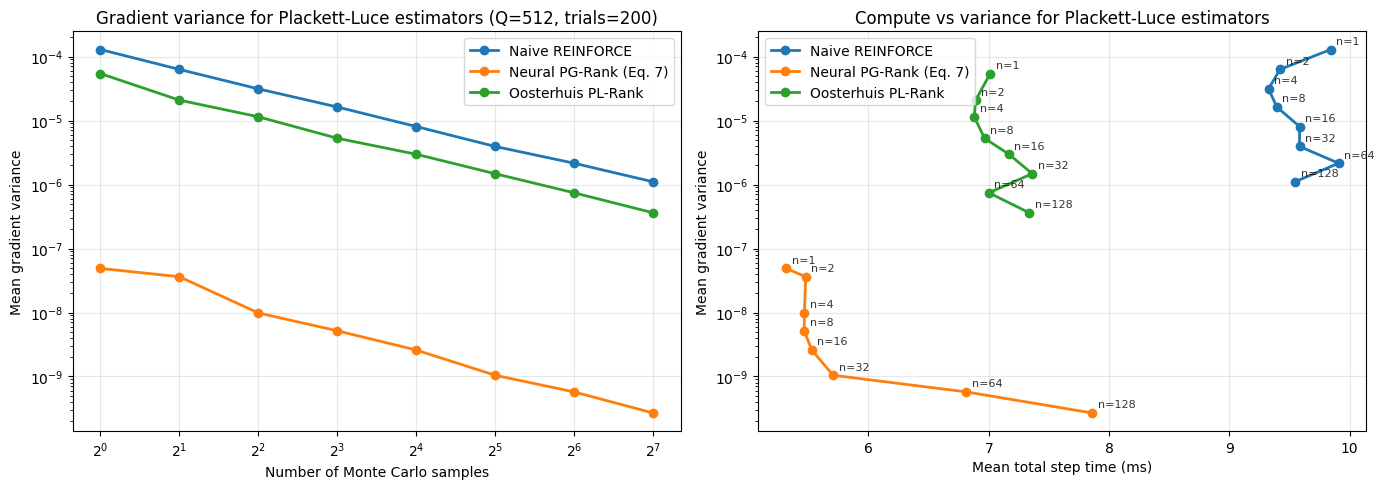

,estimator,n_samples,mean_grad_variance,mean_method_time_ms,mean_total_step_time_ms,mean_reward,mean_sampled_dcg,mean_sampled_ndcg,mean_greedy_ndcg
0,Naive REINFORCE,1,1.289083e-04,6.369373,9.843122,0.283159,0.352832,0.283159,0.556314
1,Naive REINFORCE,2,6.296829e-05,6.329003,9.421544,0.282384,0.351423,0.282384,0.556314
2,Naive REINFORCE,4,3.128822e-05,6.245569,9.326224,0.281960,0.351167,0.281960,0.556314
3,Naive REINFORCE,8,1.629917e-05,6.298887,9.395207,0.281373,0.350383,0.281373,0.556314
4,Naive REINFORCE,16,8.067231e-06,6.440412,9.583886,0.281689,0.350962,0.281689,0.556314
5,Naive REINFORCE,32,3.936784e-06,6.463398,9.584644,0.281735,0.350903,0.281735,0.556314
6,Naive REINFORCE,64,2.153635e-06,6.563284,9.909028,0.281620,0.350781,0.281620,0.556314
7,Naive REINFORCE,128,1.104189e-06,6.440876,9.546495,0.281652,0.350840,0.281652,0.556314
8,Neural PG-Rank (Eq. 7),1,4.887022e-08,4.099970,5.314260,0.081459,0.351968,0.282480,0.556314
9,Neural PG-Rank (Eq. 7),2,3.625124e-08,4.219267,5.477998,0.081620,0.351764,0.282508,0.556314


,n_samples,pl_rank_1_over_naive_reinforce,pl_rank_1_over_pg_rank,pl_rank_2_over_naive_reinforce,pl_rank_2_over_pg_rank
0,1,0.420755,1109.855122,0.525110,1385.118032
1,2,0.330965,574.884692,0.555810,965.440241
2,4,0.366217,1163.768847,0.489446,1555.368788
3,8,0.324608,1021.178748,0.509202,1601.889100
4,16,0.368607,1146.390026,0.490182,1524.499046
5,32,0.375099,1413.249409,0.433908,1634.825525
6,64,0.344940,1293.816082,0.455966,1710.259392
7,128,0.327961,1344.796009,0.466479,1912.787790


In [17]:
pl_summary_cols = [
    "estimator",
    "n_samples",
    "mean_grad_variance",
    "mean_method_time_ms",
    "mean_total_step_time_ms",
    "mean_reward",
    "mean_sampled_dcg",
    "mean_sampled_ndcg",
    "mean_greedy_ndcg",
]

pl_plot_df = pl_variance_df[pl_variance_df["estimator"].isin(pl_main_plot_estimators)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for estimator in pl_main_plot_estimators:
    sub = pl_plot_df[pl_plot_df["estimator"] == estimator]
    axes[0].plot(sub["n_samples"], sub["mean_grad_variance"], marker="o", linewidth=2, label=estimator)
    axes[1].plot(sub["mean_total_step_time_ms"], sub["mean_grad_variance"], marker="o", linewidth=2, label=estimator)
    for _, row in sub.iterrows():
        axes[1].annotate(
            f"n={int(row['n_samples'])}",
            (row["mean_total_step_time_ms"], row["mean_grad_variance"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
            alpha=0.8,
        )

axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Number of Monte Carlo samples")
axes[0].set_ylabel("Mean gradient variance")
axes[0].set_title(
    f"Gradient variance for Plackett-Luce estimators (Q={pl_plot_df['n_queries'].iloc[0]}, trials={VARIANCE_TRIALS})"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_yscale("log")
axes[1].set_xlabel("Mean total step time (ms)")
axes[1].set_ylabel("Mean gradient variance")
axes[1].set_title("Compute vs variance for Plackett-Luce estimators")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

pl_variance_pivot = pl_variance_df.pivot(index="n_samples", columns="estimator", values="mean_grad_variance")
pl_rank_ratio_cols = {
    "pl_rank_1_over_naive_reinforce": pl_variance_pivot["Oosterhuis PL-Rank"] / pl_variance_pivot["Naive REINFORCE"],
    "pl_rank_1_over_pg_rank": pl_variance_pivot["Oosterhuis PL-Rank"] / pl_variance_pivot["Neural PG-Rank (Eq. 7)"],
}
if "PL-Rank-2" in pl_variance_pivot.columns:
    pl_rank_ratio_cols["pl_rank_2_over_naive_reinforce"] = pl_variance_pivot["PL-Rank-2"] / pl_variance_pivot["Naive REINFORCE"]
    pl_rank_ratio_cols["pl_rank_2_over_pg_rank"] = pl_variance_pivot["PL-Rank-2"] / pl_variance_pivot["Neural PG-Rank (Eq. 7)"]
pl_variance_ratio_df = pd.DataFrame(pl_rank_ratio_cols).reset_index()

display(pl_plot_df[pl_summary_cols].sort_values(["estimator", "n_samples"]).reset_index(drop=True))
pl_variance_ratio_df

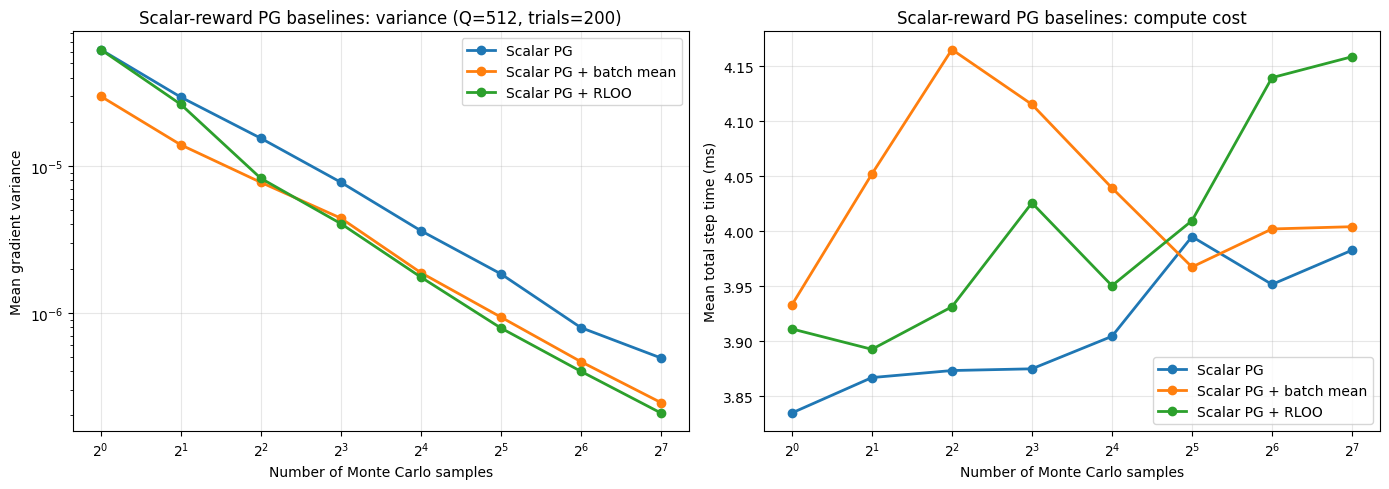

,estimator,n_samples,mean_grad_variance,mean_method_time_ms,mean_total_step_time_ms,mean_reward,mean_sampled_ndcg,mean_greedy_ndcg
0,Scalar PG,1,6.210078e-05,2.911671,3.834586,0.282480,0.282480,0.556314
1,Scalar PG,2,2.944342e-05,2.920103,3.866776,0.282508,0.282508,0.556314
2,Scalar PG,4,1.545405e-05,2.923668,3.873179,0.281714,0.281714,0.556314
3,Scalar PG,8,7.749496e-06,2.929970,3.874749,0.282227,0.282227,0.556314
4,Scalar PG,16,3.625634e-06,2.935127,3.904295,0.281838,0.281838,0.556314
5,Scalar PG,32,1.843127e-06,2.989359,3.995024,0.281823,0.281823,0.556314
6,Scalar PG,64,7.932412e-07,2.958664,3.951552,0.281639,0.281639,0.556314
7,Scalar PG,128,4.930750e-07,3.010680,3.982667,0.281804,0.281804,0.556314
8,Scalar PG + RLOO,1,6.210078e-05,2.927916,3.911058,0.282480,0.282480,0.556314
9,Scalar PG + RLOO,2,2.629778e-05,2.940318,3.892500,0.282508,0.282508,0.556314


,n_samples,batch_mean_variance_ratio,rloo_variance_ratio,batch_mean_time_ratio,rloo_time_ratio
0,1,0.480562,1.000000,1.025624,1.019943
1,2,0.473297,0.893163,1.047907,1.006653
2,4,0.500738,0.533449,1.075425,1.014974
3,8,0.569507,0.522976,1.062089,1.038966
4,16,0.517973,0.483153,1.034589,1.011802
5,32,0.507602,0.427747,0.993084,1.003632
6,64,0.586465,0.504009,1.012770,1.047610
7,128,0.496946,0.421928,1.005375,1.044209


In [18]:
# Keep the scalar-reward policy-gradient baselines as a secondary comparison.
scalar_pg_summary_cols = [
    "estimator",
    "n_samples",
    "mean_grad_variance",
    "mean_method_time_ms",
    "mean_total_step_time_ms",
    "mean_reward",
    "mean_sampled_ndcg",
    "mean_greedy_ndcg",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for estimator in scalar_pg_baseline_configs:
    sub = scalar_pg_variance_df[scalar_pg_variance_df["estimator"] == estimator]
    axes[0].plot(sub["n_samples"], sub["mean_grad_variance"], marker="o", linewidth=2, label=estimator)
    axes[1].plot(sub["n_samples"], sub["mean_total_step_time_ms"], marker="o", linewidth=2, label=estimator)

axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Number of Monte Carlo samples")
axes[0].set_ylabel("Mean gradient variance")
axes[0].set_title(
    f"Scalar-reward PG baselines: variance (Q={scalar_pg_variance_df['n_queries'].iloc[0]}, trials={VARIANCE_TRIALS})"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Number of Monte Carlo samples")
axes[1].set_ylabel("Mean total step time (ms)")
axes[1].set_title("Scalar-reward PG baselines: compute cost")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

scalar_pg_variance_pivot = scalar_pg_variance_df.pivot(index="n_samples", columns="estimator", values="mean_grad_variance")
scalar_pg_time_pivot = scalar_pg_variance_df.pivot(index="n_samples", columns="estimator", values="mean_total_step_time_ms")
scalar_pg_tradeoff_df = pd.DataFrame(
    {
        "batch_mean_variance_ratio": scalar_pg_variance_pivot["Scalar PG + batch mean"] / scalar_pg_variance_pivot["Scalar PG"],
        "rloo_variance_ratio": scalar_pg_variance_pivot["Scalar PG + RLOO"] / scalar_pg_variance_pivot["Scalar PG"],
        "batch_mean_time_ratio": scalar_pg_time_pivot["Scalar PG + batch mean"] / scalar_pg_time_pivot["Scalar PG"],
        "rloo_time_ratio": scalar_pg_time_pivot["Scalar PG + RLOO"] / scalar_pg_time_pivot["Scalar PG"],
    }
).reset_index()

display(scalar_pg_variance_df[scalar_pg_summary_cols].sort_values(["estimator", "n_samples"]).reset_index(drop=True))
scalar_pg_tradeoff_df


In [19]:
RUN_GRADIENT_DIRECTION_DIAGNOSTIC = False  # Set True for optional gradient-direction diagnostic
if RUN_GRADIENT_DIRECTION_DIAGNOSTIC:
    COSINE_N_SAMPLES_GRID = [1, 2, 4, 8, 16, 32]
'''
COSINE_N_SAMPLES_GRID = [1, 2, 4, 8, 16, 32]
COSINE_REFERENCE_SAMPLES = 64
COSINE_TRIALS = 16
COSINE_MAX_QUERIES = min(256, rank_features.shape[0])
COSINE_QUERY_SEED = 24680


def single_gradient_estimate(
    model,
    features,
    labels,
    mask,
    *,
    estimator,
    n_samples,
    topk,
    sampler=None,
    reward_type=None,
    baseline_type="none",
    reward_setup=None,
    entropy_coeff=0.0,
    gumbel_softmax_hard=False,
    tau=1.0,
    seed=0,
):
    model.zero_grad(set_to_none=True)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    loss, info = estimator_loss(
        model,
        features,
        labels,
        mask,
        n_samples=n_samples,
        topk=topk,
        estimator=estimator,
        sampler=sampler,
        tau=tau,
        reward_type=reward_type,
        baseline_type=baseline_type,
        reward_setup=reward_setup,
        entropy_coeff=entropy_coeff,
        gumbel_softmax_hard=gumbel_softmax_hard,
    )
    loss.backward()
    return flatten_grads(model).detach().cpu(), info


def gradient_cosine_experiment(
    estimator_name,
    cfg,
    *,
    n_samples_grid,
    reference_samples,
    n_trials,
    max_queries,
    query_seed,
    model_seed=RERANK_SEED,
    base_seed=8000,
):
    exp_features, exp_labels, exp_mask, exp_qids = make_experiment_batch(
        max_queries=max_queries,
        query_seed=query_seed,
    )

    model = make_ranker(seed=model_seed)
    init_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    # Use an estimator-specific high-sample average as the reference direction so
    # we do not mix objectives across the Oosterhuis and retrieval2 families.
    reference_grads = []
    for trial in range(n_trials):
        model.load_state_dict(init_state)
        grad, _ = single_gradient_estimate(
            model,
            exp_features,
            exp_labels,
            exp_mask,
            estimator=cfg["estimator"],
            sampler=cfg.get("sampler"),
            reward_type=cfg.get("reward_type"),
            baseline_type=cfg.get("baseline_type", "none"),
            n_samples=reference_samples,
            topk=RERANK_K,
            tau=cfg.get("tau", 1.0),
            reward_setup=cfg.get("reward_setup"),
            entropy_coeff=cfg.get("entropy_coeff", 0.0),
            gumbel_softmax_hard=cfg.get("gumbel_softmax_hard", False),
            seed=base_seed + 10000 + trial,
        )
        reference_grads.append(grad)

    reference_mean = torch.stack(reference_grads).mean(dim=0)
    reference_norm = reference_mean.norm().item()

    rows = []
    for n_samples in n_samples_grid:
        cosines = []
        grad_norms = []
        objective_means = []

        for trial in range(n_trials):
            model.load_state_dict(init_state)
            grad, info = single_gradient_estimate(
                model,
                exp_features,
                exp_labels,
                exp_mask,
                estimator=cfg["estimator"],
                sampler=cfg.get("sampler"),
                reward_type=cfg.get("reward_type"),
                baseline_type=cfg.get("baseline_type", "none"),
                n_samples=n_samples,
                topk=RERANK_K,
                tau=cfg.get("tau", 1.0),
                reward_setup=cfg.get("reward_setup"),
                entropy_coeff=cfg.get("entropy_coeff", 0.0),
                gumbel_softmax_hard=cfg.get("gumbel_softmax_hard", False),
                seed=base_seed + trial,
            )
            denom = max(grad.norm().item() * reference_norm, 1e-12)
            cosine = float(torch.dot(grad, reference_mean).item() / denom)
            cosines.append(cosine)
            grad_norms.append(float(grad.norm().item()))
            objective_means.append(info["mean_reward"])

        rows.append(
            {
                "estimator": estimator_name,
                "n_samples": n_samples,
                "reference_samples": reference_samples,
                "n_trials": n_trials,
                "n_queries": len(exp_qids),
                "mean_cosine_to_reference": float(np.mean(cosines)),
                "std_cosine_to_reference": float(np.std(cosines)),
                "mean_grad_norm": float(np.mean(grad_norms)),
                "std_grad_norm": float(np.std(grad_norms)),
                "mean_objective": float(np.mean(objective_means)),
            }
        )

    return pd.DataFrame(rows)


paper_cosine_df = pd.concat(
    [
        gradient_cosine_experiment(
            estimator_name=name,
            cfg=cfg,
            n_samples_grid=COSINE_N_SAMPLES_GRID,
            reference_samples=COSINE_REFERENCE_SAMPLES,
            n_trials=COSINE_TRIALS,
            max_queries=COSINE_MAX_QUERIES,
            query_seed=COSINE_QUERY_SEED,
        ).assign(comparison_family="pl_family")
        for name, cfg in paper_estimator_configs.items()
    ],
    ignore_index=True,
)

retrieval2_cosine_df = pd.concat(
    [
        gradient_cosine_experiment(
            estimator_name=name,
            cfg=cfg,
            n_samples_grid=COSINE_N_SAMPLES_GRID,
            reference_samples=COSINE_REFERENCE_SAMPLES,
            n_trials=COSINE_TRIALS,
            max_queries=COSINE_MAX_QUERIES,
            query_seed=COSINE_QUERY_SEED,
        ).assign(comparison_family="scalar_pg_family")
        for name, cfg in retrieval2_estimator_configs.items()
    ],
    ignore_index=True,
)

cosine_df = pd.concat([paper_cosine_df, retrieval2_cosine_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for estimator in paper_estimator_configs:
    sub = paper_cosine_df[paper_cosine_df["estimator"] == estimator]
    axes[0].plot(sub["n_samples"], sub["mean_cosine_to_reference"], marker="o", linewidth=2, label=estimator)

axes[0].set_xscale("log", base=2)
axes[0].set_ylim(0.0, 1.01)
axes[0].set_xlabel("Number of Monte Carlo samples")
axes[0].set_ylabel("Mean cosine to reference gradient")
axes[0].set_title(
    f"Oosterhuis gradient-direction stability (reference={COSINE_REFERENCE_SAMPLES} samples)"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for estimator in retrieval2_estimator_configs:
    sub = retrieval2_cosine_df[retrieval2_cosine_df["estimator"] == estimator]
    axes[1].plot(sub["n_samples"], sub["mean_cosine_to_reference"], marker="o", linewidth=2, label=estimator)

axes[1].set_xscale("log", base=2)
axes[1].set_ylim(0.0, 1.01)
axes[1].set_xlabel("Number of Monte Carlo samples")
axes[1].set_ylabel("Mean cosine to reference gradient")
axes[1].set_title(
    f"retrieval2 gradient-direction stability (reference={COSINE_REFERENCE_SAMPLES} samples)"
)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

cosine_summary_cols = [
    "comparison_family",
    "estimator",
    "n_samples",
    "mean_cosine_to_reference",
    "std_cosine_to_reference",
    "mean_grad_norm",
    "std_grad_norm",
    "mean_objective",
]
cosine_df[cosine_summary_cols].sort_values(["comparison_family", "estimator", "n_samples"]).reset_index(drop=True)
'''

'\nCOSINE_N_SAMPLES_GRID = [1, 2, 4, 8, 16, 32]\nCOSINE_REFERENCE_SAMPLES = 64\nCOSINE_TRIALS = 16\nCOSINE_MAX_QUERIES = min(256, rank_features.shape[0])\nCOSINE_QUERY_SEED = 24680\n\n\ndef single_gradient_estimate(\n    model,\n    features,\n    labels,\n    mask,\n    *,\n    estimator,\n    n_samples,\n    topk,\n    sampler=None,\n    reward_type=None,\n    baseline_type="none",\n    reward_setup=None,\n    entropy_coeff=0.0,\n    gumbel_softmax_hard=False,\n    tau=1.0,\n    seed=0,\n):\n    model.zero_grad(set_to_none=True)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\n    loss, info = estimator_loss(\n        model,\n        features,\n        labels,\n        mask,\n        n_samples=n_samples,\n        topk=topk,\n        estimator=estimator,\n        sampler=sampler,\n        tau=tau,\n        reward_type=reward_type,\n        baseline_type=baseline_type,\n        reward_setup=reward_setup,\n        entropy_coeff

Track: Richer-Feature Estimator Benchmark
Learned reranking benchmark: train on BEIR train, validate on BEIR dev
Train/dev query counts: 63057 / 4036
Training minibatch queries per step: 32
Train BM25 greedy nDCG@10: 0.7477
Dev BM25 greedy nDCG@10: 0.7471
Target sample budget per run: 12,800 sampled rankings
Target dev nDCG@10: 0.7491


,estimator,loss_impl,sampler,reward_type,baseline_type,tau,reward_setup,entropy_coeff,gumbel_softmax_hard,track,feature_dim,feature_source
0,Naive REINFORCE,policy_gradient,sequential,ndcg,none,1.00,default,0.00,False,richer_feature_estimator_benchmark,22,richer
1,Neural PG-Rank (Eq. 7),neural_pg_rank,retrieval2_gumbel,ndcg,paper_loo,0.05,subranking,0.01,False,richer_feature_estimator_benchmark,22,richer
2,Oosterhuis PL-Rank-1,pl_rank_1,pl_gumbel,ndcg,none,1.00,default,0.00,False,richer_feature_estimator_benchmark,22,richer


,variant,reward_form,baseline,tau,notes
0,notebook PG-Rank (Eq. 7),subranking nDCG tensor,exact leave-one-out,0.05,Main Eq. 7 comparison path in this notebook.
1,retrieval2 reward_ranking.py,subranking nDCG tensor,sample-mean subtraction labeled rloo,0.50,Release-code variant used in training scripts.
2,retrieval2 reward_ranking_scalar.py,scalar nDCG@k,global mean baseline,0.50,Scalar-reward variant; not the Eq. 7 Neural PG...
3,retrieval2 reward_ranking_f1_est.py,binary hit reward despite ndcg label,per-query sample mean,0.50,Not used by this notebook; kept only as a caut...


/tmp/ipykernel_1072/807128915.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.asarray(ys, dtype=np.float64), shifted_x) / (x1 - x0))


,estimator,n_samples,final_dev_ndcg_at_max_sample_budget,final_dev_delta_over_bm25,final_topk_changed_fraction,final_dev_ndcg_at_max_time_budget,sample_budget_to_target,time_budget_to_target,normalized_auc_sample_budget,normalized_auc_time_budget,best_dev_ndcg_within_budget,reaches_target
4,Neural PG-Rank (Eq. 7),2,0.879073,0.131969,0.999975,0.877357,461.699428,309.618524,0.849580,0.834080,0.882982,True
3,Oosterhuis PL-Rank-1,2,0.817653,0.070549,0.999740,0.812359,761.253603,498.093508,0.792481,0.785351,0.848615,True
11,Naive REINFORCE,2,0.761883,0.014779,0.993719,0.758145,1123.091569,751.544415,0.749257,0.738988,0.819758,True
5,Neural PG-Rank (Eq. 7),4,0.867119,0.120015,0.999963,0.867307,524.211976,292.283765,0.844341,0.835603,0.879500,True
0,Oosterhuis PL-Rank-1,4,0.843711,0.096607,0.999393,0.837894,865.908607,517.266429,0.797539,0.787473,0.852040,True
10,Naive REINFORCE,4,0.728689,-0.018415,0.995491,0.724107,1259.552474,590.573055,0.724552,0.718695,0.804220,True
7,Neural PG-Rank (Eq. 7),8,0.870226,0.123122,1.000000,0.870226,768.153828,317.921219,0.825625,0.820419,0.879776,True
2,Oosterhuis PL-Rank-1,8,0.837856,0.090752,0.999727,0.837856,1430.116824,638.939147,0.787718,0.781304,0.843414,True
8,Naive REINFORCE,8,0.796805,0.049701,0.991700,0.796828,2281.067775,983.085934,0.751373,0.747153,0.823942,True
6,Neural PG-Rank (Eq. 7),16,0.846386,0.099282,0.999950,0.846386,1232.677286,476.000685,0.793958,0.788231,0.859984,True


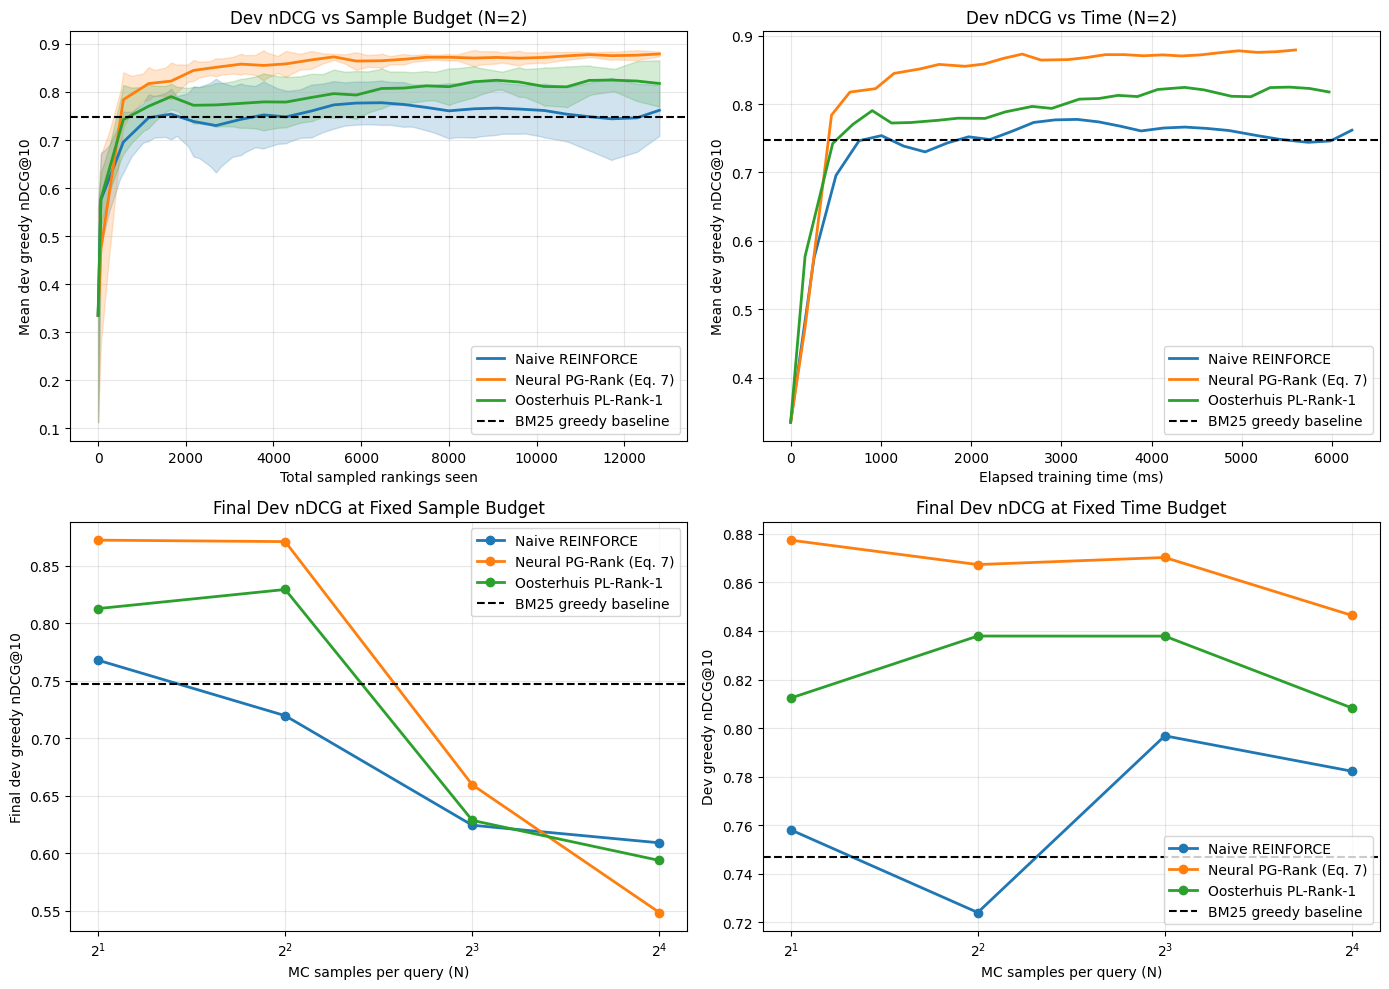

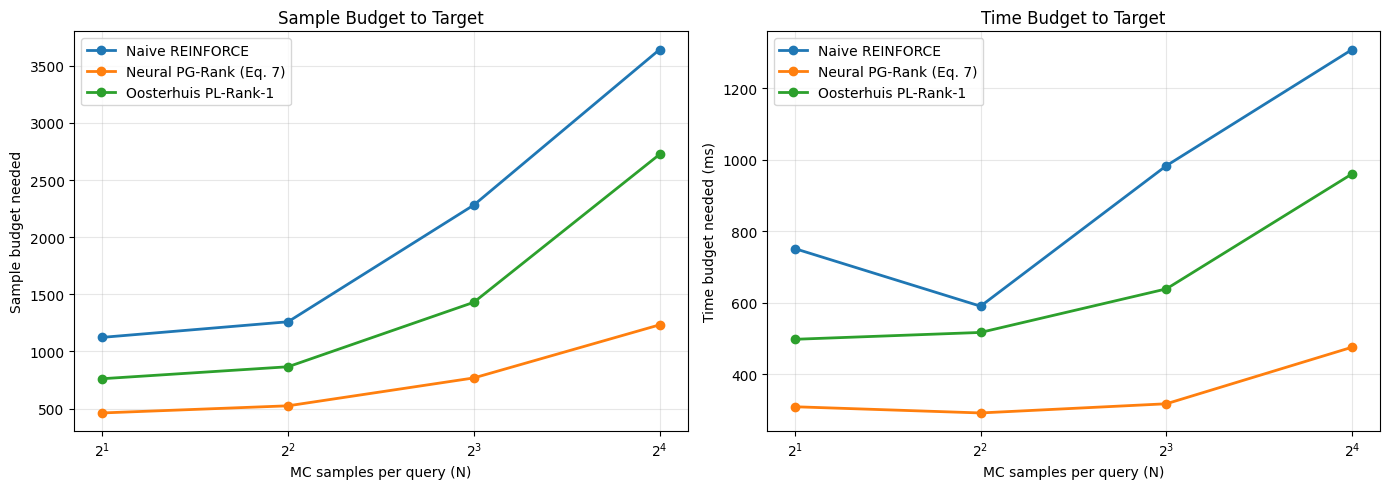

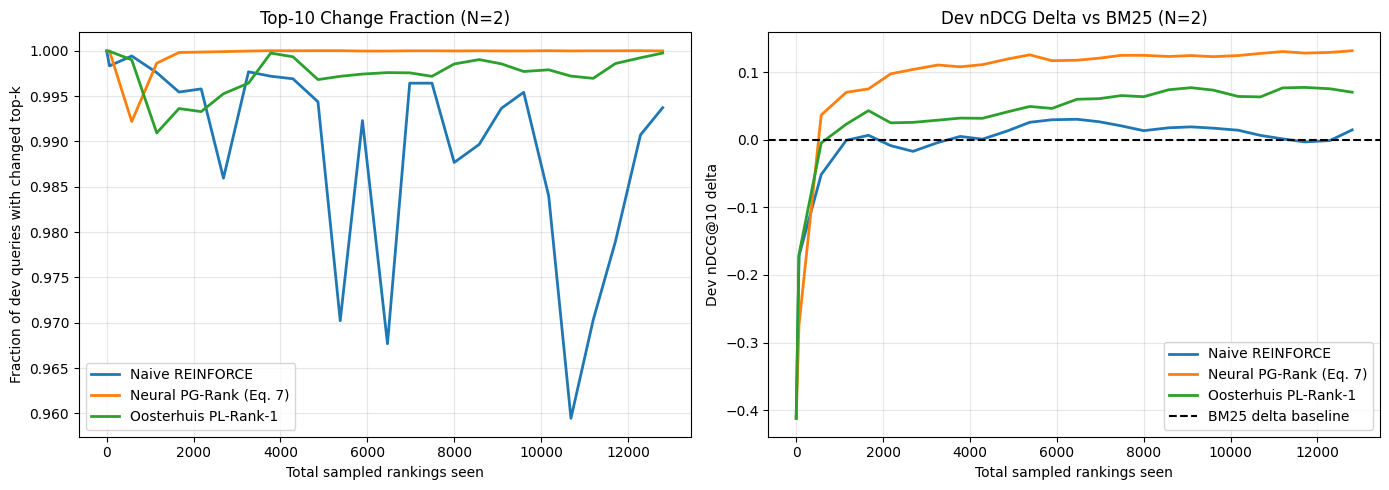

/tmp/ipykernel_1072/807128915.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.asarray(ys, dtype=np.float64), shifted_x) / (x1 - x0))


In [20]:
TRAIN_BATCH_QUERIES = min(256, rank_features.shape[0])
MINIBATCH_QUERIES = min(32, TRAIN_BATCH_QUERIES)
N_SAMPLES_GRID = [2, 4, 8, 16]
N_RUNS = 20
TRAIN_LR = 1e-2
TRAIN_INCLUDE_PL_RANK_2 = False
TARGET_SAMPLE_BUDGET = MINIBATCH_QUERIES * 200 * min(N_SAMPLES_GRID)
CHECKPOINT_COUNT = 25
TARGET_DEV_NDCG_MARGIN = 0.002
TARGET_DEV_NDCG = None

TRAIN_METHODS = {
    "Naive REINFORCE": dict(estimator="policy_gradient", sampler="sequential", reward_type="ndcg", baseline_type="none", tau=1.0),
    "Neural PG-Rank (Eq. 7)": dict(
        estimator="neural_pg_rank",
        sampler="retrieval2_gumbel",
        reward_type="ndcg",
        reward_setup="subranking",
        baseline_type="paper_loo",
        tau=0.05,
        entropy_coeff=0.01,
        gumbel_softmax_hard=False,
    ),
    "Oosterhuis PL-Rank-1": dict(estimator="pl_rank_1", sampler="pl_gumbel", reward_type="ndcg", baseline_type="none", tau=1.0),
    "PL-Rank-2": dict(estimator="pl_rank_2", sampler="pl_gumbel", reward_type="ndcg", baseline_type="none", tau=1.0),
}
TRAIN_PLOT_METHODS = [
    name for name in TRAIN_METHODS
    if TRAIN_INCLUDE_PL_RANK_2 or name != "PL-Rank-2"
]


def parameter_l2_norm(model):
    total = 0.0
    for param in model.parameters():
        total += float(param.detach().pow(2).sum().item())
    return total ** 0.5


def topk_change_metrics(model_scores, baseline_scores, mask, topk):
    pred_topk = greedy_rankings_from_scores(model_scores, mask, topk)
    baseline_topk = greedy_rankings_from_scores(baseline_scores, mask, topk)
    any_change = (pred_topk != baseline_topk).any(dim=1).to(torch.float64).mean().item()

    overlap_fractions = []
    for pred_row, base_row in zip(pred_topk.detach().cpu().tolist(), baseline_topk.detach().cpu().tolist()):
        overlap = len(set(pred_row) & set(base_row)) / max(len(base_row), 1)
        overlap_fractions.append(overlap)
    mean_overlap_fraction = float(np.mean(overlap_fractions))

    masked_scores = model_scores.masked_fill(~mask, float("-inf"))
    top_values = torch.topk(masked_scores, k=topk, dim=1).values
    score_spread = (top_values[:, 0] - top_values[:, -1]).mean().item()
    return {
        "topk_changed_fraction": float(any_change),
        "mean_topk_overlap_fraction": mean_overlap_fraction,
        "mean_topk_score_spread": float(score_spread),
    }


def package_rank_split(rank_data):
    return {
        "features": rank_data["features_by_track"][EXPERIMENT_TRACK],
        "labels": rank_data["labels"],
        "mask": rank_data["mask"],
        "qids": list(rank_data["qids"]),
        "doc_ids": list(rank_data["doc_ids"]),
        "scores": rank_data["scores"],
    }


def evaluate_split(model, split, topk):
    with torch.no_grad():
        logits = model(split["features"], split["mask"])
        greedy_values = greedy_ndcg(logits, split["labels"], split["mask"], topk)
        diagnostics = topk_change_metrics(logits, split["scores"], split["mask"], topk)
    return {
        "mean_greedy_ndcg": float(greedy_values.mean().item()),
        "dev_delta_over_bm25": float(greedy_values.mean().item() - greedy_ndcg(split["scores"], split["labels"], split["mask"], topk).mean().item()),
        **diagnostics,
    }


def build_checkpoint_steps(total_steps, checkpoint_count):
    if total_steps <= 1:
        return [0]
    checkpoints = torch.linspace(0, total_steps - 1, steps=min(checkpoint_count, total_steps))
    return sorted({int(round(v.item())) for v in checkpoints})


def interpolate_metric_at_x(xs, ys, target_x):
    if len(xs) == 0:
        return float("nan")
    if target_x <= xs[0]:
        return float(ys[0])
    if target_x >= xs[-1]:
        return float(ys[-1])
    for left in range(len(xs) - 1):
        x0 = xs[left]
        x1 = xs[left + 1]
        if x0 <= target_x <= x1:
            if x1 == x0:
                return float(ys[left + 1])
            weight = (target_x - x0) / (x1 - x0)
            return float(ys[left] + weight * (ys[left + 1] - ys[left]))
    return float(ys[-1])


def first_x_at_or_above(xs, ys, threshold):
    if len(xs) == 0:
        return float("nan")
    if ys[0] >= threshold:
        return float(xs[0])
    for left in range(len(xs) - 1):
        y0 = ys[left]
        y1 = ys[left + 1]
        if y0 < threshold <= y1:
            x0 = xs[left]
            x1 = xs[left + 1]
            if y1 == y0:
                return float(x1)
            weight = (threshold - y0) / (y1 - y0)
            return float(x0 + weight * (x1 - x0))
    return float("nan")


def normalized_auc(xs, ys):
    if len(xs) < 2:
        return float("nan")
    x0 = float(xs[0])
    x1 = float(xs[-1])
    if x1 <= x0:
        return float("nan")
    shifted_x = np.asarray(xs, dtype=np.float64) - x0
    return float(np.trapz(np.asarray(ys, dtype=np.float64), shifted_x) / (x1 - x0))


def run_budgeted_training_curve(estimator_name, cfg, n_samples, run_seed, train_split, dev_split):
    ranker = make_ranker(seed=run_seed, track_identifier=EXPERIMENT_TRACK)
    optimizer = torch.optim.Adam(ranker.parameters(), lr=TRAIN_LR)
    n_train_queries = train_split["features"].shape[0]
    minibatch_size = min(MINIBATCH_QUERIES, n_train_queries)
    total_steps = max(1, int(np.ceil(TARGET_SAMPLE_BUDGET / (minibatch_size * n_samples))))
    checkpoint_steps = build_checkpoint_steps(total_steps, CHECKPOINT_COUNT)

    rows = []
    cumulative_sample_budget = 0
    maybe_sync_cuda()
    train_start = time.perf_counter()

    initial_train_eval = evaluate_split(ranker, train_split, RERANK_K)
    initial_dev_eval = evaluate_split(ranker, dev_split, RERANK_K)
    initial_param_norm = parameter_l2_norm(ranker)
    for split_name, split_eval in [("train", initial_train_eval), ("dev", initial_dev_eval)]:
        rows.append(
            {
                "estimator": estimator_name,
                "n_samples": n_samples,
                "step": -1,
                "split": split_name,
                "loss": float("nan"),
                "mean_objective": float("nan"),
                "mean_sampled_ndcg": float("nan"),
                "mean_greedy_ndcg": split_eval["mean_greedy_ndcg"],
                "dev_delta_over_bm25": split_eval["dev_delta_over_bm25"],
                "topk_changed_fraction": split_eval["topk_changed_fraction"],
                "mean_topk_overlap_fraction": split_eval["mean_topk_overlap_fraction"],
                "mean_topk_score_spread": split_eval["mean_topk_score_spread"],
                "param_l2_norm": initial_param_norm,
                "step_time_ms": 0.0,
                "elapsed_time_ms": 0.0,
                "sample_budget_seen": 0,
                "minibatch_queries": minibatch_size,
                "total_steps": total_steps,
                "track": EXPERIMENT_TRACK,
            }
        )

    for step in range(total_steps):
        optimizer.zero_grad(set_to_none=True)
        step_seed = run_seed + 10000 + step
        torch.manual_seed(step_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(step_seed)

        batch_idx = torch.randperm(n_train_queries, device=train_split["features"].device)[:minibatch_size]
        batch_features = train_split["features"][batch_idx]
        batch_labels = train_split["labels"][batch_idx]
        batch_mask = train_split["mask"][batch_idx]

        maybe_sync_cuda()
        step_start = time.perf_counter()
        loss, info = estimator_loss(
            ranker,
            batch_features,
            batch_labels,
            batch_mask,
            n_samples=n_samples,
            topk=RERANK_K,
            tau=cfg.get("tau", 1.0),
            estimator=cfg["estimator"],
            sampler=cfg.get("sampler"),
            reward_type=cfg.get("reward_type"),
            baseline_type=cfg.get("baseline_type", "none"),
            reward_setup=cfg.get("reward_setup"),
            entropy_coeff=cfg.get("entropy_coeff", 0.0),
            gumbel_softmax_hard=cfg.get("gumbel_softmax_hard", False),
        )
        loss.backward()
        optimizer.step()
        maybe_sync_cuda()
        step_time_ms = (time.perf_counter() - step_start) * 1000.0
        elapsed_time_ms = (time.perf_counter() - train_start) * 1000.0
        cumulative_sample_budget += minibatch_size * n_samples

        if step in checkpoint_steps or step == total_steps - 1:
            train_eval = evaluate_split(ranker, train_split, RERANK_K)
            dev_eval = evaluate_split(ranker, dev_split, RERANK_K)
            param_norm = parameter_l2_norm(ranker)
            for split_name, split_eval in [("train", train_eval), ("dev", dev_eval)]:
                rows.append(
                    {
                        "estimator": estimator_name,
                        "n_samples": n_samples,
                        "step": step,
                        "split": split_name,
                        "loss": float(loss.detach().cpu()) if split_name == "train" else float("nan"),
                        "mean_objective": info["mean_reward"] if split_name == "train" else float("nan"),
                        "mean_sampled_ndcg": info["mean_sampled_ndcg"] if split_name == "train" else float("nan"),
                        "mean_greedy_ndcg": split_eval["mean_greedy_ndcg"],
                        "dev_delta_over_bm25": split_eval["dev_delta_over_bm25"],
                        "topk_changed_fraction": split_eval["topk_changed_fraction"],
                        "mean_topk_overlap_fraction": split_eval["mean_topk_overlap_fraction"],
                        "mean_topk_score_spread": split_eval["mean_topk_score_spread"],
                        "param_l2_norm": param_norm,
                        "step_time_ms": step_time_ms,
                        "elapsed_time_ms": elapsed_time_ms,
                        "sample_budget_seen": cumulative_sample_budget,
                        "minibatch_queries": minibatch_size,
                        "total_steps": total_steps,
                        "track": EXPERIMENT_TRACK,
                    }
                )

    hist = pd.DataFrame(rows)
    hist["max_sample_budget"] = cumulative_sample_budget
    return hist


train_split = package_rank_split(train_rank_data)
dev_split = package_rank_split(dev_rank_data)
assert set(train_split["qids"]).isdisjoint(set(dev_split["qids"]))

train_baseline_greedy_ndcg = greedy_ndcg(train_split["scores"], train_split["labels"], train_split["mask"], RERANK_K).mean().item()
dev_baseline_greedy_ndcg = greedy_ndcg(dev_split["scores"], dev_split["labels"], dev_split["mask"], RERANK_K).mean().item()
TARGET_DEV_NDCG = dev_baseline_greedy_ndcg + TARGET_DEV_NDCG_MARGIN

print(f"Track: {EXPERIMENT_TRACK_LABEL}")
print(f"Learned reranking benchmark: train on BEIR {BEIR_TRAIN_SPLIT}, validate on BEIR {BEIR_DEV_SPLIT}")
print(f"Train/dev query counts: {len(train_split['qids'])} / {len(dev_split['qids'])}")
print(f"Training minibatch queries per step: {min(MINIBATCH_QUERIES, len(train_split['qids']))}")
print(f"Train BM25 greedy nDCG@{RERANK_K}: {train_baseline_greedy_ndcg:.4f}")
print(f"Dev BM25 greedy nDCG@{RERANK_K}: {dev_baseline_greedy_ndcg:.4f}")
print(f"Target sample budget per run: {TARGET_SAMPLE_BUDGET:,} sampled rankings")
print(f"Target dev nDCG@{RERANK_K}: {TARGET_DEV_NDCG:.4f}")

training_smoke_df = pd.DataFrame([
    {
        "estimator": name,
        "loss_impl": cfg["estimator"],
        "sampler": cfg.get("sampler", "default"),
        "reward_type": cfg.get("reward_type", "default"),
        "baseline_type": cfg.get("baseline_type", "none"),
        "tau": cfg.get("tau", 1.0),
        "reward_setup": cfg.get("reward_setup", "default"),
        "entropy_coeff": cfg.get("entropy_coeff", 0.0),
        "gumbel_softmax_hard": cfg.get("gumbel_softmax_hard", False),
        "track": EXPERIMENT_TRACK,
        "feature_dim": rank_features.shape[-1],
        "feature_source": "richer" if EXPERIMENT_TRACK == "richer_feature_estimator_benchmark" else "bm25_demo",
    }
    for name, cfg in TRAIN_METHODS.items()
    if TRAIN_INCLUDE_PL_RANK_2 or name != "PL-Rank-2"
])
display(training_smoke_df)

pg_rank_reference_df = pd.DataFrame([
    {
        "variant": "notebook PG-Rank (Eq. 7)",
        "reward_form": "subranking nDCG tensor",
        "baseline": "exact leave-one-out",
        "tau": 0.05,
        "notes": "Main Eq. 7 comparison path in this notebook.",
    },
    {
        "variant": "retrieval2 reward_ranking.py",
        "reward_form": "subranking nDCG tensor",
        "baseline": "sample-mean subtraction labeled rloo",
        "tau": 0.5,
        "notes": "Release-code variant used in training scripts.",
    },
    {
        "variant": "retrieval2 reward_ranking_scalar.py",
        "reward_form": "scalar nDCG@k",
        "baseline": "global mean baseline",
        "tau": 0.5,
        "notes": "Scalar-reward variant; not the Eq. 7 Neural PG-Rank estimator.",
    },
    {
        "variant": "retrieval2 reward_ranking_f1_est.py",
        "reward_form": "binary hit reward despite ndcg label",
        "baseline": "per-query sample mean",
        "tau": 0.5,
        "notes": "Not used by this notebook; kept only as a cautionary reference.",
    },
])
display(pg_rank_reference_df)

import pickle

training_cache_dir = os.path.join(beir_flashrag_root, "training_cache")
os.makedirs(training_cache_dir, exist_ok=True)
training_cache_path = os.path.join(
    training_cache_dir,
    f"{BEIR_DATASET}_{BEIR_TRAIN_SPLIT}_to_{BEIR_DEV_SPLIT}_{EXPERIMENT_TRACK}_rerankk{RERANK_K}_runs{N_RUNS}_samples-{'-'.join(str(n) for n in N_SAMPLES_GRID)}.pkl",
)

if os.path.exists(training_cache_path):
    with open(training_cache_path, "rb") as handle:
        training_cache = pickle.load(handle)
    training_curve_df = training_cache["training_curve_df"]
    curve_agg_df = training_cache["curve_agg_df"]
    sample_budget_summary_df = training_cache["sample_budget_summary_df"]
    sample_budget_plot_df = training_cache["sample_budget_plot_df"]
    time_budget_summary_df = training_cache["time_budget_summary_df"]
    threshold_summary_df = training_cache["threshold_summary_df"]
    threshold_plot_df = training_cache["threshold_plot_df"]
    fixed_time_summary_df = training_cache["fixed_time_summary_df"]
    fixed_time_plot_df = training_cache["fixed_time_plot_df"]
    training_summary_df = training_cache["training_summary_df"]
    fixed_time_budget_ms = training_cache["fixed_time_budget_ms"]
    print(f"Loaded cached training results from: {training_cache_path}")
else:
    all_dfs = []
    for n_samples in N_SAMPLES_GRID:
        for run in range(N_RUNS):
            run_seed = RERANK_SEED + run
            for name, cfg in TRAIN_METHODS.items():
                hist = run_budgeted_training_curve(name, cfg, n_samples=n_samples, run_seed=run_seed, train_split=train_split, dev_split=dev_split)
                hist["run"] = run
                all_dfs.append(hist)

    training_curve_df = pd.concat(all_dfs, ignore_index=True)
    training_curve_df = training_curve_df[training_curve_df["estimator"].isin(TRAIN_PLOT_METHODS)].copy()
    assert training_curve_df["minibatch_queries"].min() == min(MINIBATCH_QUERIES, len(train_split["qids"]))

    curve_agg_df = (
        training_curve_df.groupby(["track", "estimator", "n_samples", "split", "step"])
        .agg(
            mean_greedy_ndcg_mean=("mean_greedy_ndcg", "mean"),
            mean_greedy_ndcg_std=("mean_greedy_ndcg", "std"),
            mean_sampled_ndcg_mean=("mean_sampled_ndcg", "mean"),
            mean_sampled_ndcg_std=("mean_sampled_ndcg", "std"),
            mean_objective_mean=("mean_objective", "mean"),
            mean_objective_std=("mean_objective", "std"),
            dev_delta_over_bm25_mean=("dev_delta_over_bm25", "mean"),
            topk_changed_fraction_mean=("topk_changed_fraction", "mean"),
            mean_topk_overlap_fraction_mean=("mean_topk_overlap_fraction", "mean"),
            mean_topk_score_spread_mean=("mean_topk_score_spread", "mean"),
            elapsed_time_ms_mean=("elapsed_time_ms", "mean"),
            sample_budget_seen_mean=("sample_budget_seen", "mean"),
        )
        .reset_index()
    )

    sample_budget_grid = sorted(training_curve_df["sample_budget_seen"].unique())
    per_run_sample_summary = []
    per_run_time_summary = []
    per_run_threshold_summary = []

    for (estimator, n_samples, run), run_df in training_curve_df.groupby(["estimator", "n_samples", "run"]):
        dev_df = run_df[run_df["split"] == "dev"].sort_values("sample_budget_seen")
        xs_budget = dev_df["sample_budget_seen"].to_numpy(dtype=np.float64)
        xs_time = dev_df["elapsed_time_ms"].to_numpy(dtype=np.float64)
        ys = dev_df["mean_greedy_ndcg"].to_numpy(dtype=np.float64)
        delta_ys = dev_df["dev_delta_over_bm25"].to_numpy(dtype=np.float64)
        topk_change_ys = dev_df["topk_changed_fraction"].to_numpy(dtype=np.float64)

        for budget in sample_budget_grid:
            per_run_sample_summary.append({
                "estimator": estimator,
                "n_samples": n_samples,
                "run": run,
                "sample_budget_seen": budget,
                "dev_ndcg": interpolate_metric_at_x(xs_budget, ys, budget),
                "dev_delta_over_bm25": interpolate_metric_at_x(xs_budget, delta_ys, budget),
                "topk_changed_fraction": interpolate_metric_at_x(xs_budget, topk_change_ys, budget),
            })

        per_run_time_summary.append({
            "estimator": estimator,
            "n_samples": n_samples,
            "run": run,
            "time_budget_ms": float(xs_time[-1]),
            "dev_ndcg_at_max_time_budget": float(ys[-1]),
            "normalized_auc_time_budget": normalized_auc(xs_time, ys),
        })
        per_run_threshold_summary.append({
            "estimator": estimator,
            "n_samples": n_samples,
            "run": run,
            "sample_budget_to_target": first_x_at_or_above(xs_budget, ys, TARGET_DEV_NDCG),
            "time_budget_to_target": first_x_at_or_above(xs_time, ys, TARGET_DEV_NDCG),
            "normalized_auc_sample_budget": normalized_auc(xs_budget, ys),
            "normalized_auc_time_budget": normalized_auc(xs_time, ys),
            "best_dev_ndcg_within_budget": float(np.nanmax(ys)),
        })

    sample_budget_summary_df = pd.DataFrame(per_run_sample_summary)
    sample_budget_plot_df = (
        sample_budget_summary_df.groupby(["estimator", "n_samples", "sample_budget_seen"])
        .agg(
            dev_ndcg_mean=("dev_ndcg", "mean"),
            dev_ndcg_std=("dev_ndcg", "std"),
            dev_delta_over_bm25_mean=("dev_delta_over_bm25", "mean"),
            topk_changed_fraction_mean=("topk_changed_fraction", "mean"),
        )
        .reset_index()
    )

    time_budget_summary_df = pd.DataFrame(per_run_time_summary)
    threshold_summary_df = pd.DataFrame(per_run_threshold_summary)
    threshold_plot_df = (
        threshold_summary_df.groupby(["estimator", "n_samples"])
        .agg(
            sample_budget_to_target_mean=("sample_budget_to_target", "mean"),
            time_budget_to_target_mean=("time_budget_to_target", "mean"),
            normalized_auc_sample_budget_mean=("normalized_auc_sample_budget", "mean"),
            normalized_auc_time_budget_mean=("normalized_auc_time_budget", "mean"),
            best_dev_ndcg_within_budget_mean=("best_dev_ndcg_within_budget", "mean"),
            reaches_target=("sample_budget_to_target", lambda s: bool(pd.Series(s).notna().any())),
        )
        .reset_index()
    )

    fixed_time_budget_ms = float(time_budget_summary_df.groupby("run")["time_budget_ms"].max().min())
    fixed_time_summary_rows = []
    for (estimator, n_samples, run), run_df in training_curve_df.groupby(["estimator", "n_samples", "run"]):
        dev_df = run_df[run_df["split"] == "dev"].sort_values("elapsed_time_ms")
        fixed_time_summary_rows.append({
            "estimator": estimator,
            "n_samples": n_samples,
            "run": run,
            "time_budget_ms": fixed_time_budget_ms,
            "dev_ndcg": interpolate_metric_at_x(dev_df["elapsed_time_ms"].to_numpy(dtype=np.float64), dev_df["mean_greedy_ndcg"].to_numpy(dtype=np.float64), fixed_time_budget_ms),
        })
    fixed_time_summary_df = pd.DataFrame(fixed_time_summary_rows)
    fixed_time_plot_df = fixed_time_summary_df.groupby(["estimator", "n_samples", "time_budget_ms"]).agg(dev_ndcg_mean=("dev_ndcg", "mean"), dev_ndcg_std=("dev_ndcg", "std")).reset_index()

    training_summary_df = (
        sample_budget_plot_df.sort_values("sample_budget_seen")
        .groupby(["estimator", "n_samples"])
        .tail(1)[["estimator", "n_samples", "dev_ndcg_mean", "dev_delta_over_bm25_mean", "topk_changed_fraction_mean"]]
        .rename(columns={
            "dev_ndcg_mean": "final_dev_ndcg_at_max_sample_budget",
            "dev_delta_over_bm25_mean": "final_dev_delta_over_bm25",
            "topk_changed_fraction_mean": "final_topk_changed_fraction",
        })
        .reset_index(drop=True)
    )
    training_summary_df = training_summary_df.merge(
        fixed_time_summary_df.groupby(["estimator", "n_samples"]).agg(final_dev_ndcg_at_max_time_budget=("dev_ndcg", "mean")).reset_index(),
        on=["estimator", "n_samples"],
        how="left",
    )
    training_summary_df = training_summary_df.merge(
        threshold_plot_df[[
            "estimator",
            "n_samples",
            "sample_budget_to_target_mean",
            "time_budget_to_target_mean",
            "normalized_auc_sample_budget_mean",
            "normalized_auc_time_budget_mean",
            "best_dev_ndcg_within_budget_mean",
            "reaches_target",
        ]],
        on=["estimator", "n_samples"],
        how="left",
    ).rename(columns={
        "sample_budget_to_target_mean": "sample_budget_to_target",
        "time_budget_to_target_mean": "time_budget_to_target",
        "normalized_auc_sample_budget_mean": "normalized_auc_sample_budget",
        "normalized_auc_time_budget_mean": "normalized_auc_time_budget",
        "best_dev_ndcg_within_budget_mean": "best_dev_ndcg_within_budget",
    }).sort_values(["n_samples", "final_dev_ndcg_at_max_sample_budget"], ascending=[True, False])

    training_cache = {
        "training_curve_df": training_curve_df,
        "curve_agg_df": curve_agg_df,
        "sample_budget_summary_df": sample_budget_summary_df,
        "sample_budget_plot_df": sample_budget_plot_df,
        "time_budget_summary_df": time_budget_summary_df,
        "threshold_summary_df": threshold_summary_df,
        "threshold_plot_df": threshold_plot_df,
        "fixed_time_summary_df": fixed_time_summary_df,
        "fixed_time_plot_df": fixed_time_plot_df,
        "training_summary_df": training_summary_df,
        "fixed_time_budget_ms": fixed_time_budget_ms,
    }
    with open(training_cache_path, "wb") as handle:
        pickle.dump(training_cache, handle)
    print(f"Saved cached training results to: {training_cache_path}")

display(training_summary_df)

colors = {"Naive REINFORCE": "C0", "Neural PG-Rank (Eq. 7)": "C1", "Oosterhuis PL-Rank-1": "C2", "PL-Rank-2": "C3"}
low_sample_n = min(N_SAMPLES_GRID)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for estimator in TRAIN_PLOT_METHODS:
    sub = sample_budget_plot_df[(sample_budget_plot_df["estimator"] == estimator) & (sample_budget_plot_df["n_samples"] == low_sample_n)].sort_values("sample_budget_seen")
    x = sub["sample_budget_seen"]
    y = sub["dev_ndcg_mean"]
    std = sub["dev_ndcg_std"].fillna(0)
    axes[0, 0].plot(x, y, linewidth=2, label=estimator, color=colors.get(estimator))
    axes[0, 0].fill_between(x, y - std, y + std, alpha=0.2, color=colors.get(estimator))
axes[0, 0].axhline(dev_baseline_greedy_ndcg, linestyle="--", color="black", linewidth=1.5, label="BM25 greedy baseline")
axes[0, 0].set_title(f"Dev nDCG vs Sample Budget (N={low_sample_n})")
axes[0, 0].set_xlabel("Total sampled rankings seen")
axes[0, 0].set_ylabel(f"Mean dev greedy nDCG@{RERANK_K}")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

for estimator in TRAIN_PLOT_METHODS:
    sub = curve_agg_df[(curve_agg_df["estimator"] == estimator) & (curve_agg_df["n_samples"] == low_sample_n) & (curve_agg_df["split"] == "dev")].sort_values("elapsed_time_ms_mean")
    axes[0, 1].plot(sub["elapsed_time_ms_mean"], sub["mean_greedy_ndcg_mean"], linewidth=2, label=estimator, color=colors.get(estimator))
axes[0, 1].axhline(dev_baseline_greedy_ndcg, linestyle="--", color="black", linewidth=1.5, label="BM25 greedy baseline")
axes[0, 1].set_title(f"Dev nDCG vs Time (N={low_sample_n})")
axes[0, 1].set_xlabel("Elapsed training time (ms)")
axes[0, 1].set_ylabel(f"Mean dev greedy nDCG@{RERANK_K}")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

for estimator in TRAIN_PLOT_METHODS:
    sub = sample_budget_plot_df[sample_budget_plot_df["estimator"] == estimator].sort_values("n_samples")
    final_sub = sub.groupby("n_samples").tail(1)
    axes[1, 0].plot(final_sub["n_samples"], final_sub["dev_ndcg_mean"], marker="o", linewidth=2, label=estimator, color=colors.get(estimator))
axes[1, 0].axhline(dev_baseline_greedy_ndcg, linestyle="--", color="black", linewidth=1.5, label="BM25 greedy baseline")
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].set_title("Final Dev nDCG at Fixed Sample Budget")
axes[1, 0].set_xlabel("MC samples per query (N)")
axes[1, 0].set_ylabel(f"Final dev greedy nDCG@{RERANK_K}")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

for estimator in TRAIN_PLOT_METHODS:
    sub = fixed_time_plot_df[fixed_time_plot_df["estimator"] == estimator].sort_values("n_samples")
    axes[1, 1].plot(sub["n_samples"], sub["dev_ndcg_mean"], marker="o", linewidth=2, label=estimator, color=colors.get(estimator))
axes[1, 1].axhline(dev_baseline_greedy_ndcg, linestyle="--", color="black", linewidth=1.5, label="BM25 greedy baseline")
axes[1, 1].set_xscale("log", base=2)
axes[1, 1].set_title("Final Dev nDCG at Fixed Time Budget")
axes[1, 1].set_xlabel("MC samples per query (N)")
axes[1, 1].set_ylabel(f"Dev greedy nDCG@{RERANK_K}")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

threshold_reached = bool(threshold_plot_df["reaches_target"].any())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if threshold_reached:
    for estimator in TRAIN_PLOT_METHODS:
        sub = threshold_plot_df[threshold_plot_df["estimator"] == estimator].sort_values("n_samples")
        axes[0].plot(sub["n_samples"], sub["sample_budget_to_target_mean"], marker="o", linewidth=2, label=estimator, color=colors.get(estimator))
        axes[1].plot(sub["n_samples"], sub["time_budget_to_target_mean"], marker="o", linewidth=2, label=estimator, color=colors.get(estimator))
    axes[0].set_title("Sample Budget to Target")
    axes[0].set_ylabel("Sample budget needed")
    axes[1].set_title("Time Budget to Target")
    axes[1].set_ylabel("Time budget needed (ms)")
else:
    for estimator in TRAIN_PLOT_METHODS:
        sub = training_summary_df[training_summary_df["estimator"] == estimator].sort_values("n_samples")
        axes[0].plot(sub["n_samples"], sub["best_dev_ndcg_within_budget"], marker="o", linewidth=2, label=estimator, color=colors.get(estimator))
        axes[1].plot(sub["n_samples"], sub["final_dev_delta_over_bm25"], marker="o", linewidth=2, label=estimator, color=colors.get(estimator))
    axes[0].axhline(dev_baseline_greedy_ndcg, linestyle="--", color="black", linewidth=1.5, label="BM25 greedy baseline")
    axes[0].set_title("Best dev nDCG within budget")
    axes[0].set_ylabel(f"Best dev greedy nDCG@{RERANK_K}")
    axes[1].axhline(0.0, linestyle="--", color="black", linewidth=1.5, label="BM25 delta baseline")
    axes[1].set_title("Dev nDCG delta over BM25 at fixed budget")
    axes[1].set_ylabel(f"Dev nDCG@{RERANK_K} delta")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("MC samples per query (N)")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for estimator in TRAIN_PLOT_METHODS:
    sub = sample_budget_plot_df[(sample_budget_plot_df["estimator"] == estimator) & (sample_budget_plot_df["n_samples"] == low_sample_n)].sort_values("sample_budget_seen")
    axes[0].plot(sub["sample_budget_seen"], sub["topk_changed_fraction_mean"], linewidth=2, label=estimator, color=colors.get(estimator))
    axes[1].plot(sub["sample_budget_seen"], sub["dev_delta_over_bm25_mean"], linewidth=2, label=estimator, color=colors.get(estimator))
axes[0].set_title(f"Top-{RERANK_K} Change Fraction (N={low_sample_n})")
axes[0].set_xlabel("Total sampled rankings seen")
axes[0].set_ylabel("Fraction of dev queries with changed top-k")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].axhline(0.0, linestyle="--", color="black", linewidth=1.5, label="BM25 delta baseline")
axes[1].set_title(f"Dev nDCG Delta vs BM25 (N={low_sample_n})")
axes[1].set_xlabel("Total sampled rankings seen")
axes[1].set_ylabel(f"Dev nDCG@{RERANK_K} delta")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

auc_self_check = normalized_auc(np.array([0.0, 1.0, 2.0]), np.array([0.5, 0.75, 1.0]))
assert np.isclose(auc_self_check, normalized_auc(np.array([0.0, 1.0, 2.0]), np.array([0.5, 0.75, 1.0])))
assert fixed_time_budget_ms > 0
assert rank_features.shape[-1] > 2 if EXPERIMENT_TRACK == "richer_feature_estimator_benchmark" else rank_features.shape[-1] == 2
assert training_summary_df["final_topk_changed_fraction"].max() >= 0.0


## Extension: Toy Setwise Evidence Selection

This final section extends the reranking setup to set-valued evidence selection without using an LLM. It trains on **HotpotQA train**, validates on **HotpotQA dev**, and uses the same fixed BM25 first-stage retriever for both splits.


In [ ]:
from pathlib import Path

import time

from setwise_toy_utils import (
    build_set_candidate_data,
    load_hotpot_query_payload,
    sampled_prefix_support_f1,
    support_f1_from_indices,
    resolve_hotpot_train_dev_paths,
)

TOY_SET_K = 2
TOY_SET_TOP_D = 10
TOY_HOTPOT_DATASET_DIR = Path("dataset/hotpotqa")
TOY_SET_TRAIN_PATH, TOY_SET_DEV_PATH = resolve_hotpot_train_dev_paths(TOY_HOTPOT_DATASET_DIR)
HOTPOT_TRAIN_N_QUERIES = None
HOTPOT_DEV_N_QUERIES = None

OPTION_A_N_SAMPLES_GRID = [2, 4, 8, 16]
OPTION_A_RUNS = 8
OPTION_A_VARIANCE_TRIALS = 64
OPTION_A_CHECKPOINT_COUNT = 20
OPTION_A_LR = 1e-2

OPTION_B_N_SAMPLES_GRID = [2, 4, 8, 16]
OPTION_B_RUNS = 8
OPTION_B_VARIANCE_TRIALS = 64
OPTION_B_CHECKPOINT_COUNT = 20
OPTION_B_LR = 1e-2
OPTION_B_OPTISET_BETA = 10.0
OPTION_B_OPTISET_KL_WEIGHT = 1.0


def retrieve_query_payload(query_payload, max_queries=None):
    qids = list(query_payload["qids"])
    if max_queries is not None:
        qids = qids[:max_queries]
    queries_dict = query_payload["queries"]
    queries = [queries_dict[qid] for qid in qids]
    docs, scores = beir_retriever.batch_search(queries, return_score=True)
    return {
        "qids": qids,
        "queries_dict": queries_dict,
        "support_map": query_payload["support_map"],
        "docs": docs,
        "scores": scores,
    }


def maybe_sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def flatten_grads(model):
    flat = []
    for param in model.parameters():
        grad = torch.zeros_like(param) if param.grad is None else param.grad
        flat.append(grad.detach().reshape(-1))
    return torch.cat(flat)


def build_checkpoint_steps(total_steps, checkpoint_count):
    if total_steps <= 1:
        return [0]
    checkpoints = torch.linspace(0, total_steps - 1, steps=min(checkpoint_count, total_steps))
    return sorted({int(round(value.item())) for value in checkpoints})


def interpolate_metric_at_x(xs, ys, target_x):
    if len(xs) == 0:
        return float("nan")
    if target_x <= xs[0]:
        return float(ys[0])
    if target_x >= xs[-1]:
        return float(ys[-1])
    for left in range(len(xs) - 1):
        x0 = xs[left]
        x1 = xs[left + 1]
        if x0 <= target_x <= x1:
            if x1 == x0:
                return float(ys[left + 1])
            weight = (target_x - x0) / (x1 - x0)
            return float(ys[left] + weight * (ys[left + 1] - ys[left]))
    return float(ys[-1])


def normalized_auc(xs, ys):
    if len(xs) < 2:
        return float("nan")
    x0 = float(xs[0])
    x1 = float(xs[-1])
    if x1 <= x0:
        return float("nan")
    shifted_x = np.asarray(xs, dtype=np.float64) - x0
    return float(np.trapz(np.asarray(ys, dtype=np.float64), shifted_x) / (x1 - x0))


def first_x_at_or_above(xs, ys, threshold):
    if len(xs) == 0:
        return float("nan")
    if ys[0] >= threshold:
        return float(xs[0])
    for left in range(len(xs) - 1):
        y0 = ys[left]
        y1 = ys[left + 1]
        if y0 < threshold <= y1:
            x0 = xs[left]
            x1 = xs[left + 1]
            if y1 == y0:
                return float(x1)
            weight = (threshold - y0) / (y1 - y0)
            return float(x0 + weight * (x1 - x0))
    return float("nan")


def finalize_option_b_candidate_data(candidate_data, qids):
    candidate_index = {
        tuple(candidate): idx
        for idx, candidate in enumerate(candidate_data["candidate_sets"])
    }
    baseline_choice_indices = torch.tensor(
        [
            candidate_index[tuple(indices.tolist())]
            for indices in candidate_data["baseline_set_indices"]
        ],
        dtype=torch.long,
        device=candidate_data["features"].device,
    )
    candidate_data["baseline_choice_indices"] = baseline_choice_indices
    candidate_data["baseline_utilities"] = candidate_data["utilities"].gather(
        1,
        baseline_choice_indices.unsqueeze(1),
    ).squeeze(1)
    return {
        "features": candidate_data["features"],
        "utilities": candidate_data["utilities"],
        "mask": candidate_data["mask"],
        "baseline_choice_indices": candidate_data["baseline_choice_indices"],
        "baseline_utilities": candidate_data["baseline_utilities"],
        "oracle_utilities": candidate_data["oracle_utilities"],
        "candidate_sets": candidate_data["candidate_sets"],
        "qids": list(qids),
    }


hotpot_train_payload = load_hotpot_query_payload(TOY_SET_TRAIN_PATH)
hotpot_dev_payload = load_hotpot_query_payload(TOY_SET_DEV_PATH)
retrieved_train = retrieve_query_payload(hotpot_train_payload, HOTPOT_TRAIN_N_QUERIES)
retrieved_dev = retrieve_query_payload(hotpot_dev_payload, HOTPOT_DEV_N_QUERIES)

empty_train_qrels = {qid: {} for qid in retrieved_train["qids"]}
empty_dev_qrels = {qid: {} for qid in retrieved_dev["qids"]}

toy_train_rank_data = build_rank_dataset(
    retrieved_train["qids"],
    retrieved_train["queries_dict"],
    empty_train_qrels,
    retrieved_train["docs"],
    retrieved_train["scores"],
    top_m=RERANK_TOP_M,
    require_relevant_candidate=False,
)
toy_dev_rank_data = build_rank_dataset(
    retrieved_dev["qids"],
    retrieved_dev["queries_dict"],
    empty_dev_qrels,
    retrieved_dev["docs"],
    retrieved_dev["scores"],
    top_m=RERANK_TOP_M,
    require_relevant_candidate=False,
)

option_a_train = {
    "features": toy_train_rank_data["features_by_track"][EXPERIMENT_TRACK],
    "mask": toy_train_rank_data["mask"],
    "scores": toy_train_rank_data["scores"],
    "qids": toy_train_rank_data["qids"],
    "doc_titles": toy_train_rank_data["doc_titles"],
    "gold_titles": [hotpot_train_payload["support_map"].get(qid, set()) for qid in toy_train_rank_data["qids"]],
}
option_a_dev = {
    "features": toy_dev_rank_data["features_by_track"][EXPERIMENT_TRACK],
    "mask": toy_dev_rank_data["mask"],
    "scores": toy_dev_rank_data["scores"],
    "qids": toy_dev_rank_data["qids"],
    "doc_titles": toy_dev_rank_data["doc_titles"],
    "gold_titles": [hotpot_dev_payload["support_map"].get(qid, set()) for qid in toy_dev_rank_data["qids"]],
}
option_a_full = option_a_train

option_a_train_bm25_rankings = greedy_rankings_from_scores(option_a_train["scores"], option_a_train["mask"], TOY_SET_K)
option_a_train_bm25_f1 = sampled_prefix_support_f1(
    option_a_train_bm25_rankings[:, None, :],
    option_a_train["doc_titles"],
    option_a_train["gold_titles"],
    TOY_SET_K,
)[:, 0, -1]
option_a_dev_bm25_rankings = greedy_rankings_from_scores(option_a_dev["scores"], option_a_dev["mask"], TOY_SET_K)
option_a_dev_bm25_f1 = sampled_prefix_support_f1(
    option_a_dev_bm25_rankings[:, None, :],
    option_a_dev["doc_titles"],
    option_a_dev["gold_titles"],
    TOY_SET_K,
)[:, 0, -1]


In [27]:
option_b_train_candidate_data = build_set_candidate_data(
    option_a_train["features"],
    option_a_train["scores"],
    option_a_train["mask"],
    option_a_train["doc_titles"],
    toy_train_rank_data["doc_texts"],
    option_a_train["gold_titles"],
    max_docs=TOY_SET_TOP_D,
    set_size=TOY_SET_K,
)

In [28]:
option_b_dev_candidate_data = build_set_candidate_data(
    option_a_dev["features"],
    option_a_dev["scores"],
    option_a_dev["mask"],
    option_a_dev["doc_titles"],
    toy_dev_rank_data["doc_texts"],
    option_a_dev["gold_titles"],
    max_docs=TOY_SET_TOP_D,
    set_size=TOY_SET_K,
)

In [31]:
option_b_train = finalize_option_b_candidate_data(option_b_train_candidate_data, option_a_train["qids"])
option_b_dev = finalize_option_b_candidate_data(option_b_dev_candidate_data, option_a_dev["qids"])
option_b_full = option_b_train

OPTION_A_VARIANCE_MAX_QUERIES = min(256, option_a_full["features"].shape[0])
OPTION_A_MINIBATCH_QUERIES = min(32, option_a_train["features"].shape[0])
OPTION_A_TARGET_SAMPLE_BUDGET = OPTION_A_MINIBATCH_QUERIES * 150 * min(OPTION_A_N_SAMPLES_GRID)
OPTION_B_VARIANCE_MAX_QUERIES = min(256, option_b_full["features"].shape[0])
OPTION_B_MINIBATCH_QUERIES = min(32, option_b_train["features"].shape[0])
OPTION_B_TARGET_SAMPLE_BUDGET = OPTION_B_MINIBATCH_QUERIES * 150 * min(OPTION_B_N_SAMPLES_GRID)

train_nonempty_support = sum(1 for titles in option_a_train["gold_titles"] if titles)
dev_nonempty_support = sum(1 for titles in option_a_dev["gold_titles"] if titles)

print(f"Toy support labels loaded from train/dev: {TOY_SET_TRAIN_PATH.name}, {TOY_SET_DEV_PATH.name}")
print("Candidate-generation contract: identical corpus, BM25 index, retriever config, retrieval_topk, top-M truncation, candidate filtering, feature construction, and candidate-set construction across Hotpot train/dev.")
print(f"Option A train/dev queries: {len(option_a_train['qids'])} / {len(option_a_dev['qids'])}")
print(f"Queries with non-empty gold support titles: train={train_nonempty_support}, dev={dev_nonempty_support}")
print(f"Option B train candidate-set feature shape: {tuple(option_b_train['features'].shape)}")
print(f"Option B dev candidate-set feature shape: {tuple(option_b_dev['features'].shape)}")
print(f"Option B uses {len(option_b_train_candidate_data['candidate_sets'])} candidate sets per query (C({TOY_SET_TOP_D}, {TOY_SET_K})).")
print(f"BM25 top-{TOY_SET_K} mean support-set F1: train={option_a_train_bm25_f1.mean().item():.4f}, dev={option_a_dev_bm25_f1.mean().item():.4f}")
print(f"Option B BM25 baseline mean support-set F1: train={option_b_train['baseline_utilities'].mean().item():.4f}, dev={option_b_dev['baseline_utilities'].mean().item():.4f}")
print(f"Option B oracle mean support-set F1: train={option_b_train['oracle_utilities'].mean().item():.4f}, dev={option_b_dev['oracle_utilities'].mean().item():.4f}")

assert option_b_train['features'].shape[1] == 45
assert option_b_dev['features'].shape[1] == 45
assert torch.all((option_b_train['utilities'] >= 0.0) & (option_b_train['utilities'] <= 1.0))
assert torch.all((option_b_dev['utilities'] >= 0.0) & (option_b_dev['utilities'] <= 1.0))
assert set(option_a_train['qids']).isdisjoint(set(option_a_dev['qids']))

sample_qid = option_a_dev['qids'][0]
display(pd.DataFrame({
    'sample_qid': [sample_qid],
    'gold_support_titles': [sorted(option_a_dev['gold_titles'][0])],
    'bm25_top2_titles': [[option_a_dev['doc_titles'][0][i] for i in option_a_dev_bm25_rankings[0].detach().cpu().tolist()]],
    'bm25_top2_set_f1': [float(option_a_dev_bm25_f1[0].item())],
}))

Toy support labels loaded from train/dev: train.jsonl, dev.jsonl
Candidate-generation contract: identical corpus, BM25 index, retriever config, retrieval_topk, top-M truncation, candidate filtering, feature construction, and candidate-set construction across Hotpot train/dev.
Option A train/dev queries: 90447 / 7405
Queries with non-empty gold support titles: train=90447, dev=7405
Option B train candidate-set feature shape: (90447, 45, 93)
Option B dev candidate-set feature shape: (7405, 45, 93)
Option B uses 45 candidate sets per query (C(10, 2)).
BM25 top-2 mean support-set F1: train=0.3108, dev=0.2870
Option B BM25 baseline mean support-set F1: train=0.3108, dev=0.2872
Option B oracle mean support-set F1: train=0.4403, dev=0.4113


,sample_qid,gold_support_titles,bm25_top2_titles,bm25_top2_set_f1
0,dev_0,"[ed wood, scott derrickson]","[Scott Derrickson, Sinister (film)]",0.5


In [30]:

OPTION_A_METHODS = {
    'Naive REINFORCE': dict(estimator='naive_reinforce', n_samples_grid=OPTION_A_N_SAMPLES_GRID),
    'Neural PG-Rank (Eq. 7)': dict(estimator='pg_rank_eq7', n_samples_grid=OPTION_A_N_SAMPLES_GRID),
}


def option_a_subset(split, batch_idx):
    batch_list = batch_idx.detach().cpu().tolist()
    return {
        'features': split['features'][batch_idx],
        'mask': split['mask'][batch_idx],
        'scores': split['scores'][batch_idx],
        'doc_titles': [split['doc_titles'][i] for i in batch_list],
        'gold_titles': [split['gold_titles'][i] for i in batch_list],
    }


def masked_policy_entropy(logits, mask):
    masked_logits = logits.masked_fill(~mask, float('-inf'))
    probs = F.softmax(masked_logits, dim=-1)
    log_probs = F.log_softmax(masked_logits, dim=-1)
    entropy = -(probs * log_probs).masked_fill(~mask, 0.0).sum(dim=-1)
    return entropy.mean()


def option_a_estimator_loss(model, batch, estimator_name, n_samples):
    logits = model(batch['features'], batch['mask'])
    if estimator_name == 'Naive REINFORCE':
        rankings, step_log_probs = sample_rankings_sequential(logits, batch['mask'], n_samples=n_samples, topk=TOY_SET_K)
        prefix_f1 = sampled_prefix_support_f1(rankings, batch['doc_titles'], batch['gold_titles'], TOY_SET_K)
        rewards = prefix_f1[:, :, -1]
        loss = -(step_log_probs.sum(dim=-1) * rewards.detach()).mean()
        entropy = masked_policy_entropy(logits, batch['mask'])
        return loss, {
            'mean_reward': float(rewards.mean().item()),
            'mean_prefix_f1': float(prefix_f1.mean().item()),
            'mean_final_f1': float(rewards.mean().item()),
            'entropy': float(entropy.item()),
        }

    if estimator_name == 'Neural PG-Rank (Eq. 7)':
        rankings, gathered_log_probs = sample_rankings_retrieval2_gumbel(
            logits,
            batch['mask'],
            n_samples=n_samples,
            topk=TOY_SET_K,
            tau=0.05,
            hard=False,
        )
        prefix_f1 = sampled_prefix_support_f1(rankings, batch['doc_titles'], batch['gold_titles'], TOY_SET_K)
        baseline = compute_rloo_baseline(prefix_f1)
        advantages = prefix_f1 - baseline
        entropy = masked_policy_entropy(logits, batch['mask'])
        policy_loss = -(gathered_log_probs * advantages.detach()).sum(dim=-1).mean()
        loss = policy_loss - 0.01 * entropy
        return loss, {
            'mean_reward': float(prefix_f1[:, :, -1].mean().item()),
            'mean_prefix_f1': float(prefix_f1.mean().item()),
            'mean_final_f1': float(prefix_f1[:, :, -1].mean().item()),
            'entropy': float(entropy.item()),
        }

    raise ValueError(f'Unknown Option A estimator: {estimator_name}')


def option_a_change_fraction(pred_rankings, baseline_rankings):
    pred_rows = pred_rankings.detach().cpu().tolist()
    base_rows = baseline_rankings.detach().cpu().tolist()
    changed = [float(set(pred) != set(base)) for pred, base in zip(pred_rows, base_rows)]
    return float(np.mean(changed))


def evaluate_option_a_split(model, split):
    with torch.no_grad():
        logits = model(split['features'], split['mask'])
        greedy_rankings = greedy_rankings_from_scores(logits, split['mask'], TOY_SET_K)
        greedy_f1 = sampled_prefix_support_f1(
            greedy_rankings[:, None, :],
            split['doc_titles'],
            split['gold_titles'],
            TOY_SET_K,
        )[:, 0, -1]
        baseline_rankings = greedy_rankings_from_scores(split['scores'], split['mask'], TOY_SET_K)
        baseline_f1 = sampled_prefix_support_f1(
            baseline_rankings[:, None, :],
            split['doc_titles'],
            split['gold_titles'],
            TOY_SET_K,
        )[:, 0, -1]
    return {
        'mean_selected_set_f1': float(greedy_f1.mean().item()),
        'mean_bm25_set_f1': float(baseline_f1.mean().item()),
        'delta_over_bm25': float((greedy_f1 - baseline_f1).mean().item()),
        'changed_fraction_vs_bm25': option_a_change_fraction(greedy_rankings, baseline_rankings),
        'average_set_size': float(np.mean([TOY_SET_K] * greedy_f1.shape[0])),
        'perfect_recovery_fraction': float((greedy_f1 >= 0.999).to(torch.float64).mean().item()),
    }


def run_option_a_curve(method_name, n_samples, run_seed, train_split, dev_split):
    model = make_ranker(seed=run_seed, feature_dim=train_split['features'].shape[-1], track_identifier=EXPERIMENT_TRACK)
    optimizer = torch.optim.Adam(model.parameters(), lr=OPTION_A_LR)
    n_train = train_split['features'].shape[0]
    minibatch_size = min(OPTION_A_MINIBATCH_QUERIES, n_train)
    total_steps = max(1, int(np.ceil(OPTION_A_TARGET_SAMPLE_BUDGET / (minibatch_size * n_samples))))
    checkpoint_steps = build_checkpoint_steps(total_steps, OPTION_A_CHECKPOINT_COUNT)

    rows = []
    maybe_sync_cuda()
    train_start = time.perf_counter()

    for split_name, split_eval in [('train', evaluate_option_a_split(model, train_split)), ('dev', evaluate_option_a_split(model, dev_split))]:
        rows.append({
            'estimator': method_name,
            'n_samples': n_samples,
            'run': run_seed,
            'step': -1,
            'split': split_name,
            'loss': float('nan'),
            'mean_objective': float('nan'),
            'mean_selected_set_f1': split_eval['mean_selected_set_f1'],
            'delta_over_bm25': split_eval['delta_over_bm25'],
            'changed_fraction_vs_bm25': split_eval['changed_fraction_vs_bm25'],
            'average_set_size': split_eval['average_set_size'],
            'perfect_recovery_fraction': split_eval['perfect_recovery_fraction'],
            'elapsed_time_ms': 0.0,
            'sample_budget_seen': 0,
        })

    cumulative_budget = 0
    for step in range(total_steps):
        optimizer.zero_grad(set_to_none=True)
        step_seed = run_seed + 1000 + step
        torch.manual_seed(step_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(step_seed)

        batch_idx = torch.randperm(n_train, device=train_split['features'].device)[:minibatch_size]
        batch = option_a_subset(train_split, batch_idx)

        maybe_sync_cuda()
        step_start = time.perf_counter()
        loss, info = option_a_estimator_loss(model, batch, method_name, n_samples)
        loss.backward()
        optimizer.step()
        maybe_sync_cuda()

        cumulative_budget += minibatch_size * n_samples
        elapsed_time_ms = (time.perf_counter() - train_start) * 1000.0

        if step in checkpoint_steps:
            for split_name, split_eval in [('train', evaluate_option_a_split(model, train_split)), ('dev', evaluate_option_a_split(model, dev_split))]:
                rows.append({
                    'estimator': method_name,
                    'n_samples': n_samples,
                    'run': run_seed,
                    'step': step,
                    'split': split_name,
                    'loss': float(loss.detach().cpu()),
                    'mean_objective': info['mean_reward'],
                    'mean_selected_set_f1': split_eval['mean_selected_set_f1'],
                    'delta_over_bm25': split_eval['delta_over_bm25'],
                    'changed_fraction_vs_bm25': split_eval['changed_fraction_vs_bm25'],
                    'average_set_size': split_eval['average_set_size'],
                    'perfect_recovery_fraction': split_eval['perfect_recovery_fraction'],
                    'elapsed_time_ms': elapsed_time_ms,
                    'sample_budget_seen': cumulative_budget,
                })

    return pd.DataFrame(rows)


def option_a_variance_experiment(method_name, n_samples_grid, n_trials=64, max_queries=256, query_seed=2468):
    generator = torch.Generator().manual_seed(query_seed)
    idx = torch.randperm(option_a_full['features'].shape[0], generator=generator)[:max_queries]
    batch = option_a_subset(option_a_full, idx.to(option_a_full['features'].device))
    model = make_ranker(seed=RERANK_SEED, feature_dim=option_a_full['features'].shape[-1], track_identifier=EXPERIMENT_TRACK)
    init_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    rows = []
    for n_samples in n_samples_grid:
        grads = []
        times_ms = []
        rewards = []
        for trial in range(n_trials):
            model.load_state_dict(init_state)
            model.zero_grad(set_to_none=True)
            torch.manual_seed(9000 + trial)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(9000 + trial)
            maybe_sync_cuda()
            start = time.perf_counter()
            loss, info = option_a_estimator_loss(model, batch, method_name, n_samples)
            loss.backward()
            maybe_sync_cuda()
            times_ms.append((time.perf_counter() - start) * 1000.0)
            grads.append(flatten_grads(model).detach().cpu())
            rewards.append(info['mean_reward'])
        grad_var = torch.stack(grads).var(dim=0, unbiased=False)
        rows.append({
            'estimator': method_name,
            'n_samples': n_samples,
            'mean_grad_variance': float(grad_var.mean().item()),
            'max_grad_variance': float(grad_var.max().item()),
            'mean_total_step_time_ms': float(np.mean(times_ms)),
            'mean_reward': float(np.mean(rewards)),
        })
    return pd.DataFrame(rows)


option_a_variance_df = pd.concat(
    [
        option_a_variance_experiment(name, cfg['n_samples_grid'], n_trials=OPTION_A_VARIANCE_TRIALS, max_queries=OPTION_A_VARIANCE_MAX_QUERIES)
        for name, cfg in OPTION_A_METHODS.items()
    ],
    ignore_index=True,
)

option_a_curve_df = pd.concat(
    [
        run_option_a_curve(name, n_samples, RERANK_SEED + 100 * run_idx + n_samples, option_a_train, option_a_dev)
        for name, cfg in OPTION_A_METHODS.items()
        for n_samples in cfg['n_samples_grid']
        for run_idx in range(OPTION_A_RUNS)
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for method_name in OPTION_A_METHODS:
    sub = option_a_variance_df[option_a_variance_df['estimator'] == method_name]
    axes[0, 0].plot(sub['n_samples'], sub['mean_grad_variance'], marker='o', linewidth=2, label=method_name)
    axes[0, 1].plot(sub['mean_total_step_time_ms'], sub['mean_grad_variance'], marker='o', linewidth=2, label=method_name)

low_n = min(OPTION_A_N_SAMPLES_GRID)
low_dev = option_a_curve_df[(option_a_curve_df['split'] == 'dev') & (option_a_curve_df['n_samples'] == low_n)]
low_budget = low_dev.groupby(['estimator', 'sample_budget_seen'], as_index=False).agg(
    mean_selected_set_f1=('mean_selected_set_f1', 'mean'),
    std_selected_set_f1=('mean_selected_set_f1', 'std'),
)
low_time = low_dev.groupby(['estimator', 'step'], as_index=False).agg(
    mean_elapsed_time_ms=('elapsed_time_ms', 'mean'),
    mean_selected_set_f1=('mean_selected_set_f1', 'mean'),
    std_selected_set_f1=('mean_selected_set_f1', 'std'),
)

for method_name in OPTION_A_METHODS:
    sub_budget = low_budget[low_budget['estimator'] == method_name]
    axes[1, 0].plot(sub_budget['sample_budget_seen'], sub_budget['mean_selected_set_f1'], marker='o', linewidth=2, label=method_name)
    if len(sub_budget) > 1:
        axes[1, 0].fill_between(
            sub_budget['sample_budget_seen'],
            sub_budget['mean_selected_set_f1'] - sub_budget['std_selected_set_f1'].fillna(0.0),
            sub_budget['mean_selected_set_f1'] + sub_budget['std_selected_set_f1'].fillna(0.0),
            alpha=0.15,
        )
    sub_time = low_time[low_time['estimator'] == method_name]
    axes[1, 1].plot(sub_time['mean_elapsed_time_ms'], sub_time['mean_selected_set_f1'], marker='o', linewidth=2, label=method_name)
    if len(sub_time) > 1:
        axes[1, 1].fill_between(
            sub_time['mean_elapsed_time_ms'],
            sub_time['mean_selected_set_f1'] - sub_time['std_selected_set_f1'].fillna(0.0),
            sub_time['mean_selected_set_f1'] + sub_time['std_selected_set_f1'].fillna(0.0),
            alpha=0.15,
        )

for ax in [axes[1, 0], axes[1, 1]]:
    ax.axhline(float(option_a_bm25_f1.mean().item()), linestyle='--', color='black', linewidth=1.5, label='BM25 top-k baseline')

axes[0, 0].set_xscale('log', base=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Option A Variance')
axes[0, 0].set_xlabel('MC samples per query')
axes[0, 0].set_ylabel('Mean gradient variance')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Option A Compute vs Variance')
axes[0, 1].set_xlabel('Mean step time (ms)')
axes[0, 1].set_ylabel('Mean gradient variance')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].set_title(f'Option A Dev Set F1 vs Budget (N={low_n})')
axes[1, 0].set_xlabel('Sample budget seen')
axes[1, 0].set_ylabel('Mean selected-set F1')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].set_title(f'Option A Dev Set F1 vs Time (N={low_n})')
axes[1, 1].set_xlabel('Elapsed training time (ms)')
axes[1, 1].set_ylabel('Mean selected-set F1')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

option_a_final_dev = option_a_curve_df[option_a_curve_df['split'] == 'dev'].sort_values(['estimator', 'n_samples', 'run', 'sample_budget_seen']).groupby(['estimator', 'n_samples', 'run']).tail(1)
option_a_summary = option_a_final_dev.groupby(['estimator', 'n_samples'], as_index=False).agg(
    final_dev_set_f1=('mean_selected_set_f1', 'mean'),
    final_dev_delta_over_bm25=('delta_over_bm25', 'mean'),
    perfect_recovery_fraction=('perfect_recovery_fraction', 'mean'),
    changed_fraction_vs_bm25=('changed_fraction_vs_bm25', 'mean'),
)

display(option_a_summary)


KeyboardInterrupt: 

In [ ]:

OPTION_B_METHODS = {
    'OptiSet-inspired CE+KL': dict(kind='optiset', n_samples_grid=[1]),
    'REINFORCE-over-sets': dict(kind='stochastic', estimator='policy_gradient', sampler='sequential', reward_type='dcg', n_samples_grid=OPTION_B_N_SAMPLES_GRID),
    'PL-over-sets (PL-Rank-1)': dict(kind='stochastic', estimator='pl_rank_1', sampler='pl_gumbel', reward_type='dcg', n_samples_grid=OPTION_B_N_SAMPLES_GRID),
}


def make_option_b_ranker(seed):
    return make_ranker(
        seed=seed,
        feature_dim=option_b_full['features'].shape[-1],
        track_identifier=EXPERIMENT_TRACK,
    )


def option_b_entropy(logits, mask):
    masked_logits = logits.masked_fill(~mask, float('-inf'))
    probs = F.softmax(masked_logits, dim=-1)
    log_probs = F.log_softmax(masked_logits, dim=-1)
    entropy = -(probs * log_probs).masked_fill(~mask, 0.0).sum(dim=-1)
    return entropy.mean()


def option_b_optiset_loss(model, features, utilities, mask, beta=OPTION_B_OPTISET_BETA, kl_weight=OPTION_B_OPTISET_KL_WEIGHT):
    logits = model(features, mask)
    masked_logits = logits.masked_fill(~mask, float('-inf'))
    target_scores = torch.where(mask, utilities, torch.full_like(utilities, float('-inf')))
    best_idx = target_scores.argmax(dim=1)

    log_probs = F.log_softmax(masked_logits, dim=-1)
    ce = F.nll_loss(log_probs, best_idx)

    target_logits = torch.where(mask, beta * utilities, torch.full_like(utilities, float('-inf')))
    target_probs = F.softmax(target_logits, dim=-1)
    target_log_probs = torch.log(target_probs.clamp_min(1e-12))
    kl = (target_probs * (target_log_probs - log_probs)).masked_fill(~mask, 0.0).sum(dim=-1).mean()
    loss = ce + kl_weight * kl

    chosen = masked_logits.argmax(dim=1)
    selected_utilities = utilities.gather(1, chosen.unsqueeze(1)).squeeze(1)
    return loss, {
        'mean_reward': float(selected_utilities.mean().item()),
        'ce': float(ce.detach().cpu()),
        'kl': float(kl.detach().cpu()),
        'mean_entropy': float(option_b_entropy(logits, mask).detach().cpu()),
    }


def option_b_stochastic_loss(model, features, utilities, mask, cfg, n_samples):
    loss, info = estimator_loss(
        model,
        features,
        utilities,
        mask,
        n_samples=n_samples,
        topk=1,
        estimator=cfg['estimator'],
        sampler=cfg['sampler'],
        reward_type=cfg['reward_type'],
        baseline_type='none',
        tau=1.0,
    )
    info['mean_reward'] = info['mean_reward']
    return loss, info


def evaluate_option_b_split(model, split):
    with torch.no_grad():
        logits = model(split['features'], split['mask'])
        masked_logits = logits.masked_fill(~split['mask'], float('-inf'))
        chosen = masked_logits.argmax(dim=1)
        selected_utilities = split['utilities'].gather(1, chosen.unsqueeze(1)).squeeze(1)
        baseline_utilities = split['baseline_utilities']
        oracle_utilities = split['oracle_utilities']
    return {
        'mean_selected_set_f1': float(selected_utilities.mean().item()),
        'mean_bm25_set_f1': float(baseline_utilities.mean().item()),
        'delta_over_bm25': float((selected_utilities - baseline_utilities).mean().item()),
        'oracle_gap': float((oracle_utilities - selected_utilities).mean().item()),
        'changed_fraction_vs_bm25': float((chosen != split['baseline_choice_indices']).to(torch.float64).mean().item()),
        'average_set_size': float(np.mean([TOY_SET_K] * selected_utilities.shape[0])),
        'perfect_recovery_fraction': float((selected_utilities >= 0.999).to(torch.float64).mean().item()),
    }


def option_b_subset(split, batch_idx):
    return {
        'features': split['features'][batch_idx],
        'utilities': split['utilities'][batch_idx],
        'mask': split['mask'][batch_idx],
        'baseline_choice_indices': split['baseline_choice_indices'][batch_idx],
        'baseline_utilities': split['baseline_utilities'][batch_idx],
        'oracle_utilities': split['oracle_utilities'][batch_idx],
    }


def run_option_b_curve(method_name, cfg, n_samples, run_seed, train_split, dev_split):
    model = make_option_b_ranker(run_seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=OPTION_B_LR)
    n_train = train_split['features'].shape[0]
    minibatch_size = min(OPTION_B_MINIBATCH_QUERIES, n_train)
    effective_samples = max(1, n_samples)
    total_steps = max(1, int(np.ceil(OPTION_B_TARGET_SAMPLE_BUDGET / (minibatch_size * effective_samples))))
    checkpoint_steps = build_checkpoint_steps(total_steps, OPTION_B_CHECKPOINT_COUNT)

    rows = []
    maybe_sync_cuda()
    train_start = time.perf_counter()

    for split_name, split_eval in [('train', evaluate_option_b_split(model, train_split)), ('dev', evaluate_option_b_split(model, dev_split))]:
        rows.append({
            'estimator': method_name,
            'n_samples': n_samples,
            'run': run_seed,
            'step': -1,
            'split': split_name,
            'loss': float('nan'),
            'mean_objective': float('nan'),
            'mean_selected_set_f1': split_eval['mean_selected_set_f1'],
            'delta_over_bm25': split_eval['delta_over_bm25'],
            'oracle_gap': split_eval['oracle_gap'],
            'changed_fraction_vs_bm25': split_eval['changed_fraction_vs_bm25'],
            'average_set_size': split_eval['average_set_size'],
            'perfect_recovery_fraction': split_eval['perfect_recovery_fraction'],
            'elapsed_time_ms': 0.0,
            'sample_budget_seen': 0,
        })

    cumulative_budget = 0
    for step in range(total_steps):
        optimizer.zero_grad(set_to_none=True)
        step_seed = run_seed + 4000 + step
        torch.manual_seed(step_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(step_seed)

        batch_idx = torch.randperm(n_train, device=train_split['features'].device)[:minibatch_size]
        batch = option_b_subset(train_split, batch_idx)

        maybe_sync_cuda()
        if cfg['kind'] == 'optiset':
            loss, info = option_b_optiset_loss(model, batch['features'], batch['utilities'], batch['mask'])
            effective_step_samples = 1
        else:
            loss, info = option_b_stochastic_loss(model, batch['features'], batch['utilities'], batch['mask'], cfg, n_samples)
            effective_step_samples = n_samples
        loss.backward()
        optimizer.step()
        maybe_sync_cuda()

        cumulative_budget += minibatch_size * effective_step_samples
        elapsed_time_ms = (time.perf_counter() - train_start) * 1000.0

        if step in checkpoint_steps:
            for split_name, split_eval in [('train', evaluate_option_b_split(model, train_split)), ('dev', evaluate_option_b_split(model, dev_split))]:
                rows.append({
                    'estimator': method_name,
                    'n_samples': n_samples,
                    'run': run_seed,
                    'step': step,
                    'split': split_name,
                    'loss': float(loss.detach().cpu()),
                    'mean_objective': info['mean_reward'],
                    'mean_selected_set_f1': split_eval['mean_selected_set_f1'],
                    'delta_over_bm25': split_eval['delta_over_bm25'],
                    'oracle_gap': split_eval['oracle_gap'],
                    'changed_fraction_vs_bm25': split_eval['changed_fraction_vs_bm25'],
                    'average_set_size': split_eval['average_set_size'],
                    'perfect_recovery_fraction': split_eval['perfect_recovery_fraction'],
                    'elapsed_time_ms': elapsed_time_ms,
                    'sample_budget_seen': cumulative_budget,
                })

    return pd.DataFrame(rows)


def option_b_variance_experiment(method_name, cfg, n_samples_grid, n_trials=64, max_queries=256, query_seed=97531):
    generator = torch.Generator().manual_seed(query_seed)
    idx = torch.randperm(option_b_full['features'].shape[0], generator=generator)[:max_queries]
    batch = option_b_subset(option_b_full, idx.to(option_b_full['features'].device))
    model = make_option_b_ranker(RERANK_SEED)
    init_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    rows = []
    for n_samples in n_samples_grid:
        grads = []
        times_ms = []
        rewards = []
        for trial in range(n_trials):
            model.load_state_dict(init_state)
            model.zero_grad(set_to_none=True)
            torch.manual_seed(12000 + trial)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(12000 + trial)
            maybe_sync_cuda()
            start = time.perf_counter()
            if cfg['kind'] == 'optiset':
                loss, info = option_b_optiset_loss(model, batch['features'], batch['utilities'], batch['mask'])
            else:
                loss, info = option_b_stochastic_loss(model, batch['features'], batch['utilities'], batch['mask'], cfg, n_samples)
            loss.backward()
            maybe_sync_cuda()
            grads.append(flatten_grads(model).detach().cpu())
            times_ms.append((time.perf_counter() - start) * 1000.0)
            rewards.append(info['mean_reward'])
        grad_var = torch.stack(grads).var(dim=0, unbiased=False)
        rows.append({
            'estimator': method_name,
            'n_samples': n_samples,
            'mean_grad_variance': float(grad_var.mean().item()),
            'mean_total_step_time_ms': float(np.mean(times_ms)),
            'mean_reward': float(np.mean(rewards)),
        })
    return pd.DataFrame(rows)


option_b_variance_df = pd.concat(
    [
        option_b_variance_experiment(
            method_name,
            cfg,
            cfg['n_samples_grid'],
            n_trials=OPTION_B_VARIANCE_TRIALS,
            max_queries=OPTION_B_VARIANCE_MAX_QUERIES,
        )
        for method_name, cfg in OPTION_B_METHODS.items()
    ],
    ignore_index=True,
)

option_b_curve_df = pd.concat(
    [
        run_option_b_curve(method_name, cfg, n_samples, RERANK_SEED + 500 * run_idx + 10 * n_samples, option_b_train, option_b_dev)
        for method_name, cfg in OPTION_B_METHODS.items()
        for n_samples in cfg['n_samples_grid']
        for run_idx in range(OPTION_B_RUNS)
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for method_name, cfg in OPTION_B_METHODS.items():
    sub = option_b_variance_df[option_b_variance_df['estimator'] == method_name]
    axes[0, 0].plot(sub['n_samples'], sub['mean_grad_variance'], marker='o', linewidth=2, label=method_name)
    axes[0, 1].plot(sub['mean_total_step_time_ms'], sub['mean_grad_variance'], marker='o', linewidth=2, label=method_name)

low_n = min(OPTION_B_N_SAMPLES_GRID)
low_dev = option_b_curve_df[
    (option_b_curve_df['split'] == 'dev')
    & (
        ((option_b_curve_df['estimator'] == 'OptiSet CE+KL') & (option_b_curve_df['n_samples'] == 1))
        | ((option_b_curve_df['estimator'] != 'OptiSet CE+KL') & (option_b_curve_df['n_samples'] == low_n))
    )
]
low_budget = low_dev.groupby(['estimator', 'sample_budget_seen'], as_index=False).agg(
    mean_selected_set_f1=('mean_selected_set_f1', 'mean'),
    std_selected_set_f1=('mean_selected_set_f1', 'std'),
)
low_time = low_dev.groupby(['estimator', 'step'], as_index=False).agg(
    mean_elapsed_time_ms=('elapsed_time_ms', 'mean'),
    mean_selected_set_f1=('mean_selected_set_f1', 'mean'),
    std_selected_set_f1=('mean_selected_set_f1', 'std'),
)

for method_name in OPTION_B_METHODS:
    sub_budget = low_budget[low_budget['estimator'] == method_name]
    axes[1, 0].plot(sub_budget['sample_budget_seen'], sub_budget['mean_selected_set_f1'], marker='o', linewidth=2, label=method_name)
    if len(sub_budget) > 1:
        axes[1, 0].fill_between(
            sub_budget['sample_budget_seen'],
            sub_budget['mean_selected_set_f1'] - sub_budget['std_selected_set_f1'].fillna(0.0),
            sub_budget['mean_selected_set_f1'] + sub_budget['std_selected_set_f1'].fillna(0.0),
            alpha=0.15,
        )
    sub_time = low_time[low_time['estimator'] == method_name]
    axes[1, 1].plot(sub_time['mean_elapsed_time_ms'], sub_time['mean_selected_set_f1'], marker='o', linewidth=2, label=method_name)
    if len(sub_time) > 1:
        axes[1, 1].fill_between(
            sub_time['mean_elapsed_time_ms'],
            sub_time['mean_selected_set_f1'] - sub_time['std_selected_set_f1'].fillna(0.0),
            sub_time['mean_selected_set_f1'] + sub_time['std_selected_set_f1'].fillna(0.0),
            alpha=0.15,
        )

for ax in [axes[1, 0], axes[1, 1]]:
    ax.axhline(float(option_b_candidate_data['baseline_utilities'].mean().item()), linestyle='--', color='black', linewidth=1.5, label='BM25 top-k baseline')
    ax.axhline(float(option_b_candidate_data['oracle_utilities'].mean().item()), linestyle=':', color='gray', linewidth=1.5, label='Oracle best set')

axes[0, 0].set_xscale('log', base=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Option B Variance')
axes[0, 0].set_xlabel('MC samples per query')
axes[0, 0].set_ylabel('Mean gradient variance')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Option B Compute vs Variance')
axes[0, 1].set_xlabel('Mean step time (ms)')
axes[0, 1].set_ylabel('Mean gradient variance')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].set_title('Option B Dev Set F1 vs Budget')
axes[1, 0].set_xlabel('Optimization budget seen')
axes[1, 0].set_ylabel('Mean selected-set F1')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].set_title('Option B Dev Set F1 vs Time')
axes[1, 1].set_xlabel('Elapsed training time (ms)')
axes[1, 1].set_ylabel('Mean selected-set F1')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

option_b_final_dev = option_b_curve_df[option_b_curve_df['split'] == 'dev'].sort_values(['estimator', 'n_samples', 'run', 'sample_budget_seen']).groupby(['estimator', 'n_samples', 'run']).tail(1)
option_b_summary = option_b_final_dev.groupby(['estimator', 'n_samples'], as_index=False).agg(
    final_dev_set_f1=('mean_selected_set_f1', 'mean'),
    final_dev_delta_over_bm25=('delta_over_bm25', 'mean'),
    oracle_gap=('oracle_gap', 'mean'),
    perfect_recovery_fraction=('perfect_recovery_fraction', 'mean'),
    changed_fraction_vs_bm25=('changed_fraction_vs_bm25', 'mean'),
)

display(option_b_summary)


In [24]:
# retrieval cache: save
import os
import pickle

beir_cache_dir = os.path.join(beir_flashrag_root, "retrieval_cache")
os.makedirs(beir_cache_dir, exist_ok=True)

cache_payload = {
    "dataset": BEIR_DATASET,
    "retrieval_topk": BEIR_RETRIEVAL_TOPK,
    "splits": {},
}

for split_name, payload in beir_retrieval.items():
    cache_payload["splits"][split_name] = {
        "qids": payload["qids"],
        "docs": payload["docs"],
        "scores": payload["scores"],
        "results": payload["results"],
        "metrics": payload["metrics"],
    }

cache_path = os.path.join(
    beir_cache_dir,
    f"{BEIR_DATASET}_shared_bm25_top{BEIR_RETRIEVAL_TOPK}.pkl",
)

with open(cache_path, "wb") as f:
    pickle.dump(cache_payload, f)

print(f"Saved retrieval cache to: {cache_path}")

Saved retrieval cache to: /content/drive/MyDrive/FlashRAG/beir_hotpotqa_flashrag/retrieval_cache/hotpotqa_shared_bm25_top100.pkl


In [25]:
import os
print(os.path.exists(cache_path), os.path.getsize(cache_path))
import pickle

with open(cache_path, "rb") as f:
    test_cache = pickle.load(f)

print(test_cache.keys())
print(test_cache["splits"].keys())


True 5927358455
dict_keys(['dataset', 'retrieval_topk', 'splits'])
dict_keys(['train', 'dev', 'test'])


In [34]:
# save
import os
import pickle

training_cache_dir = os.path.join(beir_flashrag_root, "training_cache")
os.makedirs(training_cache_dir, exist_ok=True)

training_cache_path = os.path.join(
    training_cache_dir,
    f"{BEIR_DATASET}_{BEIR_TRAIN_SPLIT}_to_{BEIR_DEV_SPLIT}_{EXPERIMENT_TRACK}_rerankk{RERANK_K}_runs{N_RUNS}_samples-{'-'.join(str(n) for n in N_SAMPLES_GRID)}.pkl",
)

training_cache = {
    "training_curve_df": training_curve_df,
    "curve_agg_df": curve_agg_df,
    "sample_budget_summary_df": sample_budget_summary_df,
    "sample_budget_plot_df": sample_budget_plot_df,
    "time_budget_summary_df": time_budget_summary_df,
    "threshold_summary_df": threshold_summary_df,
    "threshold_plot_df": threshold_plot_df,
    "fixed_time_summary_df": fixed_time_summary_df,
    "fixed_time_plot_df": fixed_time_plot_df,
    "training_summary_df": training_summary_df,
    "fixed_time_budget_ms": fixed_time_budget_ms,
}

with open(training_cache_path, "wb") as handle:
    pickle.dump(training_cache, handle)

print(f"Saved cached training results to: {training_cache_path}")


Saved cached training results to: /content/drive/MyDrive/FlashRAG/beir_hotpotqa_flashrag/training_cache/hotpotqa_train_to_dev_richer_feature_estimator_benchmark_rerankk10_runs20_samples-2-4-8-16.pkl


In [32]:
# save
import os
import pickle

setwise_cache_dir = os.path.join(beir_flashrag_root, "setwise_cache")
os.makedirs(setwise_cache_dir, exist_ok=True)

setwise_setup_cache_path = os.path.join(
    setwise_cache_dir,
    f"{EXPERIMENT_TRACK}_hotpot_train_dev_topd{TOY_SET_TOP_D}_setk{TOY_SET_K}.pkl",
)

setwise_setup_cache = {
    "hotpot_train_payload": hotpot_train_payload,
    "hotpot_dev_payload": hotpot_dev_payload,
    "retrieved_train": retrieved_train,
    "retrieved_dev": retrieved_dev,
    "toy_train_rank_data": toy_train_rank_data,
    "toy_dev_rank_data": toy_dev_rank_data,
    "option_a_train": option_a_train,
    "option_a_dev": option_a_dev,
    "option_a_full": option_a_full,
    "option_a_train_bm25_rankings": option_a_train_bm25_rankings,
    "option_a_train_bm25_f1": option_a_train_bm25_f1,
    "option_a_dev_bm25_rankings": option_a_dev_bm25_rankings,
    "option_a_dev_bm25_f1": option_a_dev_bm25_f1,
    "option_b_train_candidate_data": option_b_train_candidate_data,
    "option_b_dev_candidate_data": option_b_dev_candidate_data,
    "option_b_train": option_b_train,
    "option_b_dev": option_b_dev,
    "option_b_full": option_b_full,
    "OPTION_A_VARIANCE_MAX_QUERIES": OPTION_A_VARIANCE_MAX_QUERIES,
    "OPTION_A_MINIBATCH_QUERIES": OPTION_A_MINIBATCH_QUERIES,
    "OPTION_A_TARGET_SAMPLE_BUDGET": OPTION_A_TARGET_SAMPLE_BUDGET,
    "OPTION_B_VARIANCE_MAX_QUERIES": OPTION_B_VARIANCE_MAX_QUERIES,
    "OPTION_B_MINIBATCH_QUERIES": OPTION_B_MINIBATCH_QUERIES,
    "OPTION_B_TARGET_SAMPLE_BUDGET": OPTION_B_TARGET_SAMPLE_BUDGET,
    "train_nonempty_support": train_nonempty_support,
    "dev_nonempty_support": dev_nonempty_support,
}

with open(setwise_setup_cache_path, "wb") as handle:
    pickle.dump(setwise_setup_cache, handle)

print(f"Saved setwise setup cache to: {setwise_setup_cache_path}")


Saved setwise setup cache to: /content/drive/MyDrive/FlashRAG/beir_hotpotqa_flashrag/setwise_cache/richer_feature_estimator_benchmark_hotpot_train_dev_topd10_setk2.pkl
